# Sensitivity Matrix & V-Mode Information Analysis

**Comprehensive analysis of the AOS sensitivity matrix SVD decomposition and v-mode properties**

**Author:** Aaron Roodman  
**Date Created:** 2026-03-08  
**Keywords:** Rubin Observatory, AOS, Sensitivity Matrix, SVD, V-modes, Control, Double-Zernike

## Description

This notebook provides a comprehensive analysis of the Rubin AOS sensitivity matrix
and its SVD decomposition, following the formalism in *AOS Control Equations*.

**Sections:**
1. Build the raw and normalized sensitivity matrices A and Ã
2. SVD decomposition: U, Σ, V and their physical interpretation
3. V-mode composition in DOF space (normalized and physical units)
4. V-mode wavefront signatures (Zernike patterns)
5. Control equations: v-mode amplitudes, DOF corrections, round-trip tests
6. Noise amplification and information content per mode
7. Control gain analysis and convergence
8. Comparison across DOF sets (10, 22, 30, 50)
9. Summary table
10. Double-Zernike v-mode decomposition and crosstalk analysis

**Conventions:**
- V-modes are numbered starting from **1** (not 0)
- Truncation: 10 DOF → 10 v-modes, 22+ DOF → 12 v-modes

**Based on:**
- AOS Control Equations reference document
- ts_ofc sensitivity matrix infrastructure
- truncation_thresholds.ipynb (predecessor notebook)

<a id='Setup' ></a>
## Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.ticker as ticker
from matplotlib import colors, cm
from lsst.ts.ofc import OFC, OFCData, SensitivityMatrix

%load_ext autoreload
%autoreload 2
%matplotlib inline

<a id='Configuration' ></a>
## Configuration

In [2]:
# --- DOF labels (all 50) ---
labels_50dof = [
    'M2_dz', 'M2_dx', 'M2_dy', 'M2_rx', 'M2_ry',
    'Cam_dz', 'Cam_dx', 'Cam_dy', 'Cam_rx', 'Cam_ry',
    'B1_1', 'B1_2', 'B1_3', 'B1_4', 'B1_5',
    'B1_6', 'B1_7', 'B1_8', 'B1_9', 'B1_10',
    'B1_11', 'B1_12', 'B1_13', 'B1_14', 'B1_15',
    'B1_16', 'B1_17', 'B1_18', 'B1_19', 'B1_20',
    'B2_1', 'B2_2', 'B2_3', 'B2_4', 'B2_5',
    'B2_6', 'B2_7', 'B2_8', 'B2_9', 'B2_10',
    'B2_11', 'B2_12', 'B2_13', 'B2_14', 'B2_15',
    'B2_16', 'B2_17', 'B2_18', 'B2_19', 'B2_20',
]

# --- DOF subsets ---
dof_sets = {
    'hexapod_10': list(range(0, 10)),
    'standard_22': list(range(0, 17)) + list(range(30, 35)),
    'extended_30': list(range(0, 20)) + list(range(30, 40)),
    'all_50': list(range(0, 50)),
}

# --- Zernike selection (from Josh's message) ---
zn = np.array([4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 22, 23, 24, 25, 26])
zn_idx = zn - 4
n_zernike = len(zn_idx)

# --- WFS corners ---
sensor_name_list = ['R00_SW0', 'R04_SW0', 'R40_SW0', 'R44_SW0']
n_wfs = len(sensor_name_list)

# --- Default DOF set for detailed analysis ---
default_dof_set = 'standard_22'

# --- V-mode truncation: how many modes to retain for each DOF set ---
# 10 DOF: use all 10;  22+ DOF: use first 12
n_modes_truncated = {
    'hexapod_10': 10,
    'standard_22': 12,
    'extended_30': 12,
    'all_50': 12,
}

# --- Markers for multi-line plots ---
marker_cycle = ['o', 's', '^', 'D', 'v', 'P', '*', 'X', 'h', 'p', '<', '>']

print(f'Zernike terms: {zn} ({n_zernike} terms)')
print(f'WFS sensors: {sensor_name_list} ({n_wfs} sensors)')
print(f'Measurement vector size: {n_zernike} x {n_wfs} = {n_zernike * n_wfs}')
for name, dofs in dof_sets.items():
    ntrunc = n_modes_truncated[name]
    print(f'DOF set "{name}": {len(dofs)} DOFs, truncated to {ntrunc} v-modes')

Zernike terms: [ 4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 22 23 24 25 26] (21 terms)
WFS sensors: ['R00_SW0', 'R04_SW0', 'R40_SW0', 'R44_SW0'] (4 sensors)
Measurement vector size: 21 x 4 = 84
DOF set "hexapod_10": 10 DOFs, truncated to 10 v-modes
DOF set "standard_22": 22 DOFs, truncated to 12 v-modes
DOF set "extended_30": 30 DOFs, truncated to 12 v-modes
DOF set "all_50": 50 DOFs, truncated to 12 v-modes


<a id='Sensitivity Matrix' ></a>
## 1. Sensitivity Matrix

Build the raw sensitivity matrix **A** and the normalized matrix **Ã = A @ diag(n_j)**.

- **A** maps physical DOF motions to Zernike wavefront changes (units: microns/Zernike per physical DOF unit)
- **Ã** normalizes each DOF column by n_j = r_j × f_j, placing all DOFs on equal (dimensionless) footing

In [3]:
# Load OFC data and build the sensitivity matrix at the 4 corner WFS positions
ofc_data = OFCData('lsst', config_dir='/home/r/roodman/u/LSST/packages/ts_config_mttcs/MTAOS/v8/ofc')

field_angles = [ofc_data.sample_points[sensor] for sensor in sensor_name_list]
print('Field angles (deg):', field_angles)

dz_sensitivity_matrix = SensitivityMatrix(ofc_data)
sens_3d = dz_sensitivity_matrix.evaluate(field_angles, 0.0)
print(f'Raw 3D sensitivity matrix shape: {sens_3d.shape}  (n_wfs, n_zernike_full, n_dof_full)')

# Select Zernike subset and reshape to 2D: rows = (Zernike x WFS), cols = DOFs
sens_3d = sens_3d[:, zn_idx, :]
A_full = sens_3d.reshape((-1, sens_3d.shape[2]))

# Select active DOF indices
A_full = A_full[:, ofc_data.dof_idx]
print(f'Raw sensitivity matrix A shape: {A_full.shape}  (n_zernike*n_wfs, n_dof)')

# Normalization vector n_j for each DOF
norm_vector = ofc_data.normalization_weights[ofc_data.dof_idx]
print(f'Normalization vector shape: {norm_vector.shape}')

# Normalized sensitivity matrix: Atilde = A @ diag(n_j)
Atilde_full = A_full @ np.diag(norm_vector)
print(f'Normalized sensitivity matrix Ã shape: {Atilde_full.shape}')

Field angles (deg): [[-1.1902777777777778, -1.1902777777777778], [-1.1902777777777778, 1.1902777777777778], [1.1902777777777778, -1.1902777777777778], [1.1902777777777778, 1.1902777777777778]]
Raw 3D sensitivity matrix shape: (4, 25, 50)  (n_wfs, n_zernike_full, n_dof_full)
Raw sensitivity matrix A shape: (84, 50)  (n_zernike*n_wfs, n_dof)
Normalization vector shape: (50,)
Normalized sensitivity matrix Ã shape: (84, 50)


### 1.1 Sensitivity Matrix Visualization

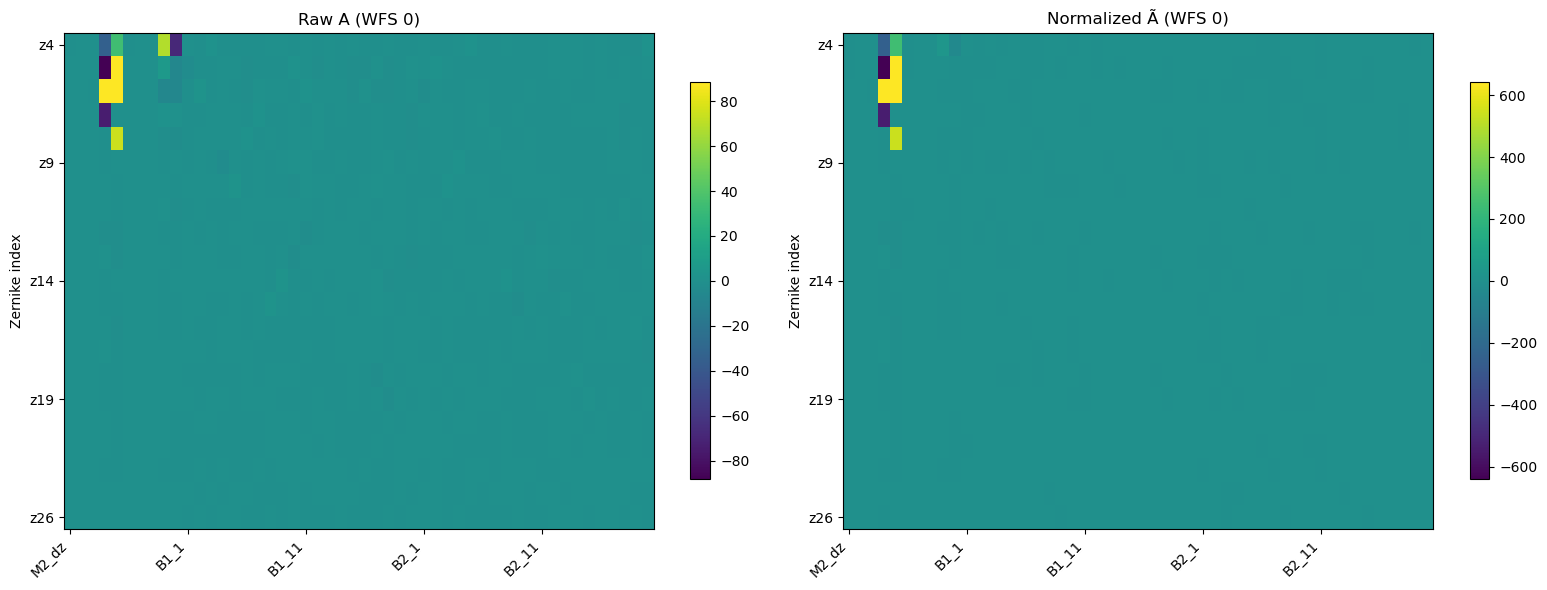

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Raw A (first WFS only for clarity)
r0 = axes[0].imshow(A_full[:n_zernike, :], aspect='auto')
axes[0].set_title('Raw A (WFS 0)')
axes[0].set_ylabel('Zernike index')
axes[0].set_yticks(range(0, n_zernike, 5), [f'z{zn[i]}' for i in range(0, n_zernike, 5)])
xt = np.arange(0, 50, 10)
axes[0].set_xticks(xt, [labels_50dof[i] for i in xt], rotation=45, ha='right')
fig.colorbar(r0, ax=axes[0], shrink=0.8)

# Normalized Atilde (first WFS only)
r1 = axes[1].imshow(Atilde_full[:n_zernike, :], aspect='auto')
axes[1].set_title('Normalized Ã (WFS 0)')
axes[1].set_ylabel('Zernike index')
axes[1].set_yticks(range(0, n_zernike, 5), [f'z{zn[i]}' for i in range(0, n_zernike, 5)])
axes[1].set_xticks(xt, [labels_50dof[i] for i in xt], rotation=45, ha='right')
fig.colorbar(r1, ax=axes[1], shrink=0.8)

fig.tight_layout()
plt.show()

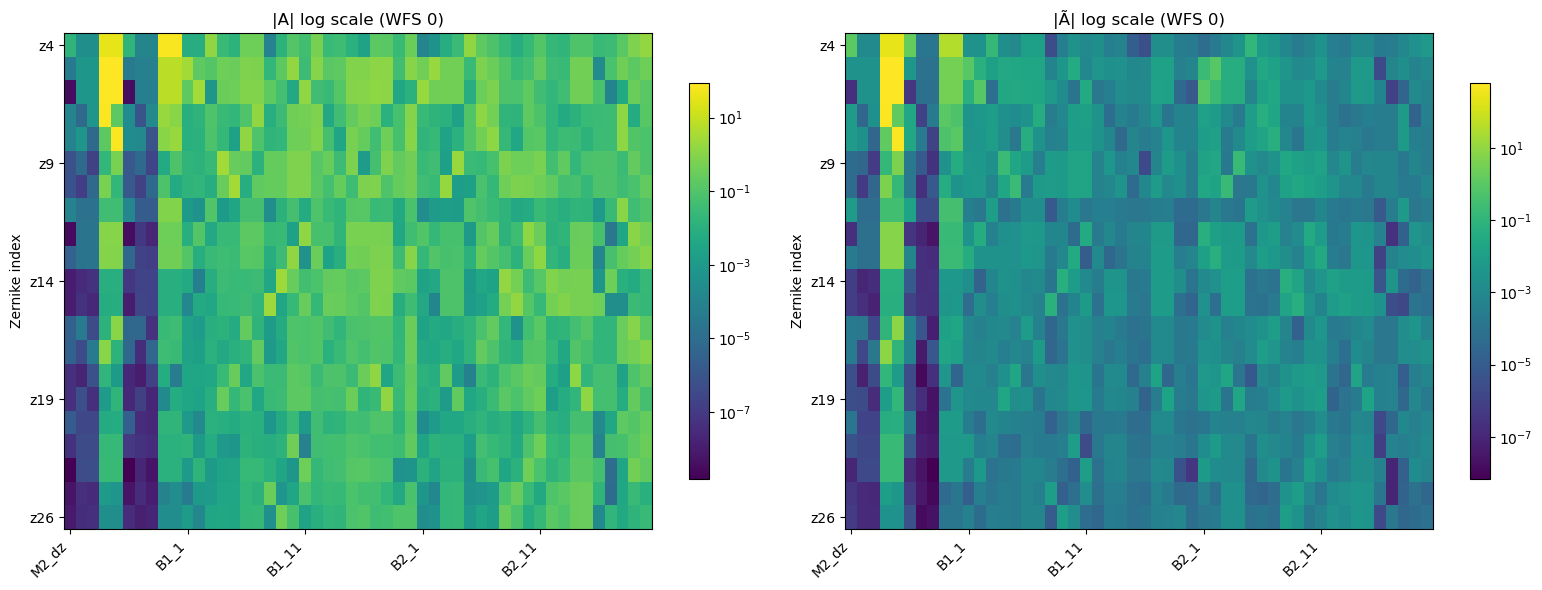

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# |A| log scale
r0 = axes[0].imshow(np.abs(A_full[:n_zernike, :]), aspect='auto', norm=colors.LogNorm())
axes[0].set_title('|A| log scale (WFS 0)')
axes[0].set_ylabel('Zernike index')
axes[0].set_yticks(range(0, n_zernike, 5), [f'z{zn[i]}' for i in range(0, n_zernike, 5)])
xt = np.arange(0, 50, 10)
axes[0].set_xticks(xt, [labels_50dof[i] for i in xt], rotation=45, ha='right')
fig.colorbar(r0, ax=axes[0], shrink=0.8)

# |Atilde| log scale
r1 = axes[1].imshow(np.abs(Atilde_full[:n_zernike, :]), aspect='auto', norm=colors.LogNorm())
axes[1].set_title('|Ã| log scale (WFS 0)')
axes[1].set_ylabel('Zernike index')
axes[1].set_yticks(range(0, n_zernike, 5), [f'z{zn[i]}' for i in range(0, n_zernike, 5)])
axes[1].set_xticks(xt, [labels_50dof[i] for i in xt], rotation=45, ha='right')
fig.colorbar(r1, ax=axes[1], shrink=0.8)

fig.tight_layout()
plt.show()

### 1.2 Normalization Weights

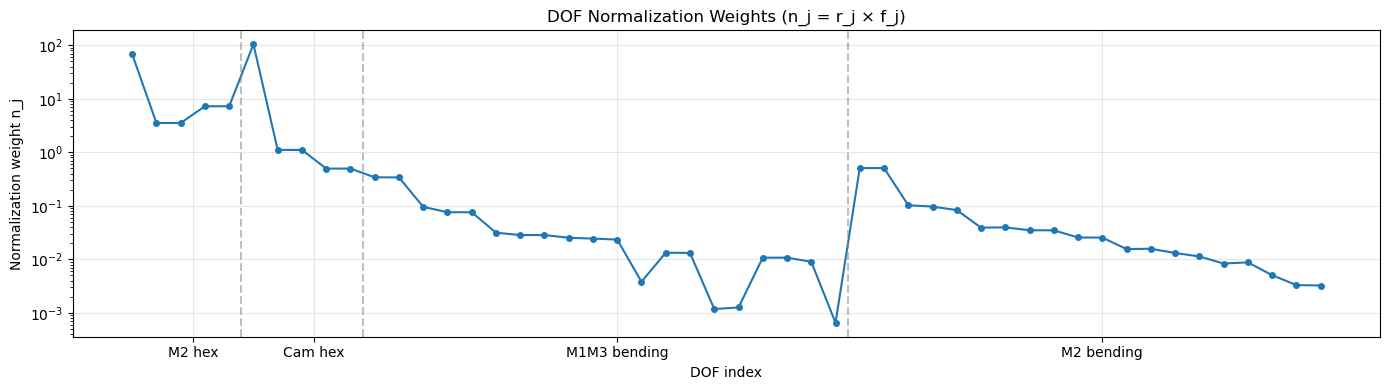

In [6]:
fig, ax = plt.subplots(1, 1, figsize=(14, 4))
ax.semilogy(norm_vector, 'o-', markersize=4)
ax.set_xlabel('DOF index')
ax.set_ylabel('Normalization weight n_j')
ax.set_title('DOF Normalization Weights (n_j = r_j × f_j)')
# Mark boundaries
for xv in [5, 10, 30]:
    ax.axvline(xv - 0.5, color='gray', ls='--', alpha=0.5)
ax.set_xticks([2.5, 7.5, 20, 40], ['M2 hex', 'Cam hex', 'M1M3 bending', 'M2 bending'])
ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()

<a id='SVD Decomposition' ></a>
## 2. SVD Decomposition

Decompose the normalized sensitivity matrix: **Ã = U Σ Vᵀ**

- **U** (n_z×n_wfs, n_modes): left singular vectors — Zernike measurement patterns
- **Σ** (n_modes, n_modes): singular values — wavefront change per unit dimensionless DOF motion
- **V** (n_dof, n_modes): right singular vectors — DOF composition of each v-mode

In [7]:
def compute_svd(Atilde, dof_indices, labels_all=labels_50dof):
    """Compute SVD of Atilde restricted to given DOF indices.
    
    Returns dict with keys: U, s, V, dof_indices, labels, Atilde_sub
    """
    Atilde_sub = Atilde[:, dof_indices]
    U, s, Vh = np.linalg.svd(Atilde_sub, full_matrices=False)
    V = Vh.T
    labels_sub = [labels_all[i] for i in dof_indices]
    return dict(U=U, s=s, V=V, dof_indices=dof_indices, labels=labels_sub,
                Atilde_sub=Atilde_sub, n_modes=len(s))

# Compute SVD for each DOF set
svd_results = {}
for name, dof_idx_list in dof_sets.items():
    svd_results[name] = compute_svd(Atilde_full, dof_idx_list)
    r = svd_results[name]
    print(f'{name:15s}: {r["n_modes"]:3d} modes, '
          f'σ_max={r["s"][0]:.2f}, σ_min={r["s"][-1]:.2e}, '
          f'condition number={r["s"][0]/r["s"][-1]:.1f}')

hexapod_10     :  10 modes, σ_max=2161.10, σ_min=4.07e-04, condition number=5315203.5
standard_22    :  22 modes, σ_max=2161.10, σ_min=5.82e-05, condition number=37125498.6
extended_30    :  30 modes, σ_max=2161.10, σ_min=3.41e-05, condition number=63382866.1
all_50         :  50 modes, σ_max=2161.10, σ_min=1.03e-05, condition number=209774716.2


### 2.1 Singular Value Spectrum

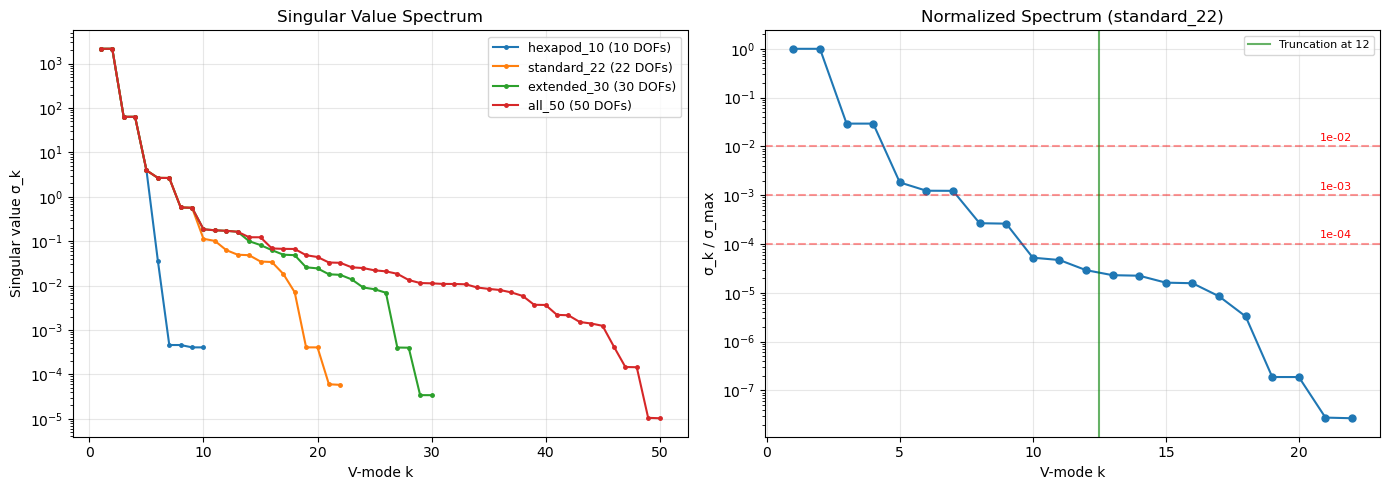

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: overlay all DOF sets (1-indexed v-modes)
for name, r in svd_results.items():
    axes[0].semilogy(np.arange(1, r['n_modes'] + 1), r['s'], '.-', markersize=5,
                     label=f'{name} ({r["n_modes"]} DOFs)')
axes[0].set_xlabel('V-mode k')
axes[0].set_ylabel('Singular value σ_k')
axes[0].set_title('Singular Value Spectrum')
axes[0].legend(fontsize=9)
axes[0].grid(alpha=0.3)

# Right: normalized σ_k / σ_max for the default set
r = svd_results[default_dof_set]
s_norm = r['s'] / r['s'][0]
axes[1].semilogy(np.arange(1, r['n_modes'] + 1), s_norm, 'o-', markersize=5)
for thresh in [1e-2, 1e-3, 1e-4]:
    axes[1].axhline(thresh, color='red', ls='--', alpha=0.4)
    axes[1].text(r['n_modes'], thresh * 1.3, f'{thresh:.0e}', color='red', fontsize=8, ha='right')
n_trunc = n_modes_truncated[default_dof_set]
axes[1].axvline(n_trunc + 0.5, color='green', ls='-', alpha=0.6, label=f'Truncation at {n_trunc}')
axes[1].set_xlabel('V-mode k')
axes[1].set_ylabel('σ_k / σ_max')
axes[1].set_title(f'Normalized Spectrum ({default_dof_set})')
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.3)

fig.tight_layout()
plt.show()

### 2.2 Mode Truncation

Modes with σ_k < threshold × σ_max are truncated. Show how many modes survive at each threshold.

In [9]:
thresholds = [1e-2, 1e-3, 1e-4, 1e-5]

print(f'{"DOF set":>15s} {"n_DOF":>6s} {"n_trunc":>8s}', end='')
for t in thresholds:
    print(f'  thresh={t:.0e}', end='')
print()

for name, r in svd_results.items():
    n_trunc = n_modes_truncated[name]
    print(f'{name:>15s} {len(r["dof_indices"]):>6d} {n_trunc:>8d}', end='')
    for t in thresholds:
        n_kept = np.sum(r['s'] > t * r['s'][0])
        print(f'  {n_kept:>12d}', end='')
    print()

print(f'\nRetained v-modes per DOF set:')
for name, n_trunc in n_modes_truncated.items():
    r = svd_results[name]
    print(f'  {name}: v-modes 1–{n_trunc} of {r["n_modes"]}  '
          f'(σ_{n_trunc}/σ_1 = {r["s"][n_trunc-1]/r["s"][0]:.2e})')

        DOF set  n_DOF  n_trunc  thresh=1e-02  thresh=1e-03  thresh=1e-04  thresh=1e-05
     hexapod_10     10       10             4             5             5             6
    standard_22     22       12             4             7             9            16
    extended_30     30       12             4             7             9            20
         all_50     50       12             4             7             9            25

Retained v-modes per DOF set:
  hexapod_10: v-modes 1–10 of 10  (σ_10/σ_1 = 1.88e-07)
  standard_22: v-modes 1–12 of 22  (σ_12/σ_1 = 2.92e-05)
  extended_30: v-modes 1–12 of 30  (σ_12/σ_1 = 7.95e-05)
  all_50: v-modes 1–12 of 50  (σ_12/σ_1 = 7.95e-05)


<a id='V-Mode Analysis' ></a>
## 3. V-Mode Analysis

Each column of V defines a v-mode: a unit vector in DOF space.
V_jk is the contribution of dimensionless DOF j to v-mode k.

### 3.1 V-Mode Composition in DOF Space

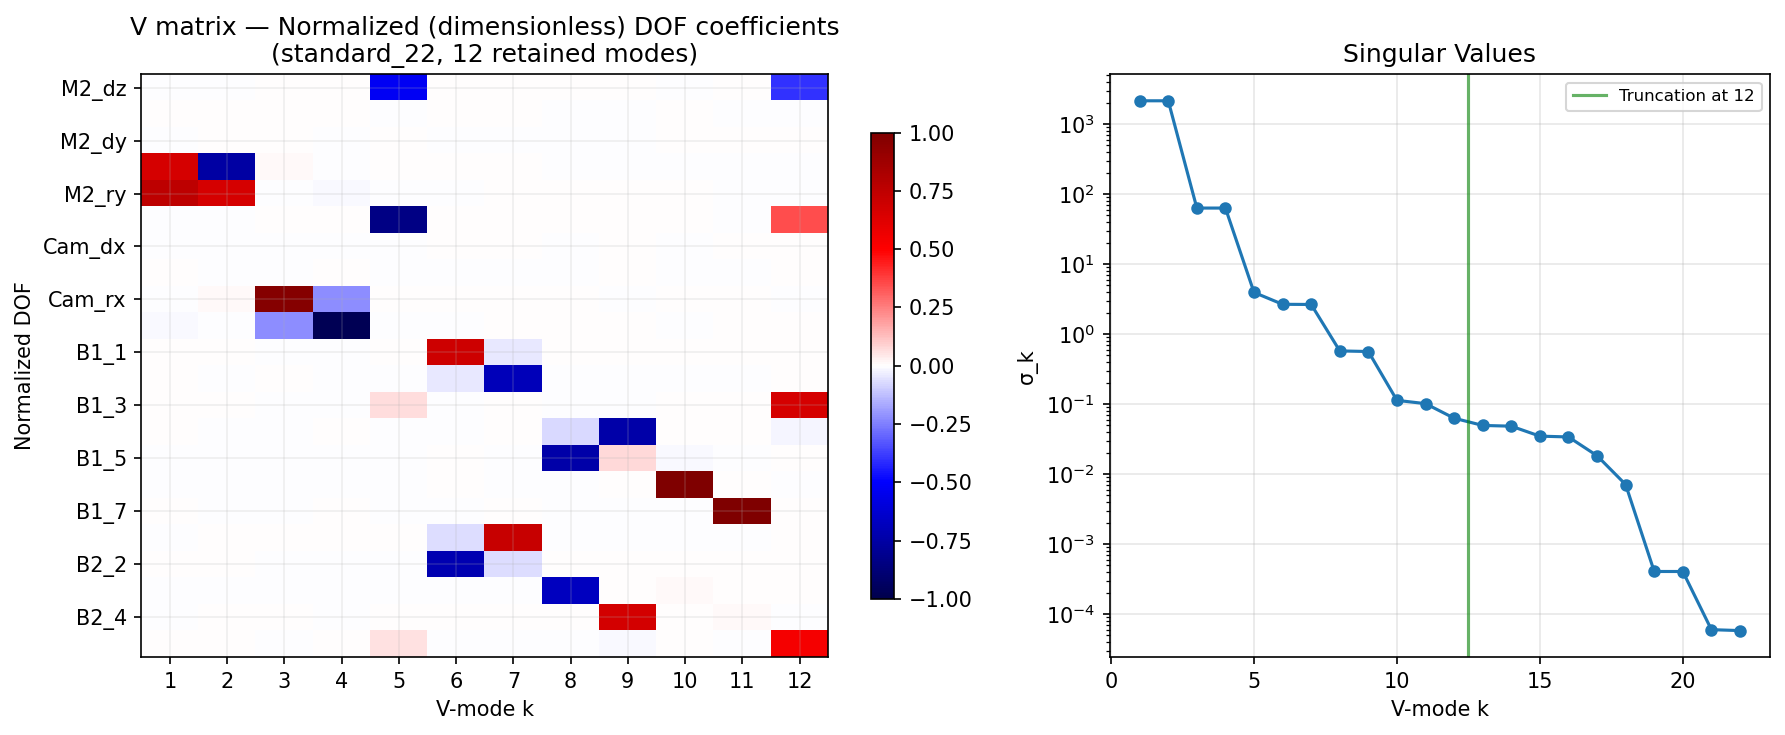

In [10]:
r = svd_results[default_dof_set]
V = r['V']
s = r['s']
n_dof_sub = len(r['dof_indices'])
labels_sub = r['labels']
n_trunc = n_modes_truncated[default_dof_set]

fig = plt.figure(figsize=(12, 5), dpi=150)
gs = gridspec.GridSpec(1, 2, width_ratios=[1.3, 1])
ax0 = plt.subplot(gs[0])
ax1 = plt.subplot(gs[1])

# V matrix heatmap (show retained modes only)
im = ax0.imshow(V[:, :n_trunc], cmap='seismic', vmin=-1, vmax=1, aspect='auto')
ax0.set_xlabel('V-mode k')
ax0.set_xticks(range(n_trunc), [str(k+1) for k in range(n_trunc)])
ax0.set_ylabel('Normalized DOF')
yt = range(0, n_dof_sub, max(1, n_dof_sub // 8))
ax0.set_yticks(list(yt), [labels_sub[i] for i in yt])
ax0.set_title(f'V matrix — Normalized (dimensionless) DOF coefficients\n({default_dof_set}, {n_trunc} retained modes)')
fig.colorbar(im, ax=ax0, shrink=0.8)
ax0.grid(alpha=0.2)

# Singular values (1-indexed)
ax1.semilogy(np.arange(1, len(s) + 1), s, 'o-', markersize=5)
ax1.axvline(n_trunc + 0.5, color='green', ls='-', alpha=0.6, label=f'Truncation at {n_trunc}')
ax1.set_xlabel('V-mode k')
ax1.set_ylabel('σ_k')
ax1.set_title('Singular Values')
ax1.legend(fontsize=8)
ax1.grid(alpha=0.3)

fig.tight_layout()
plt.show()

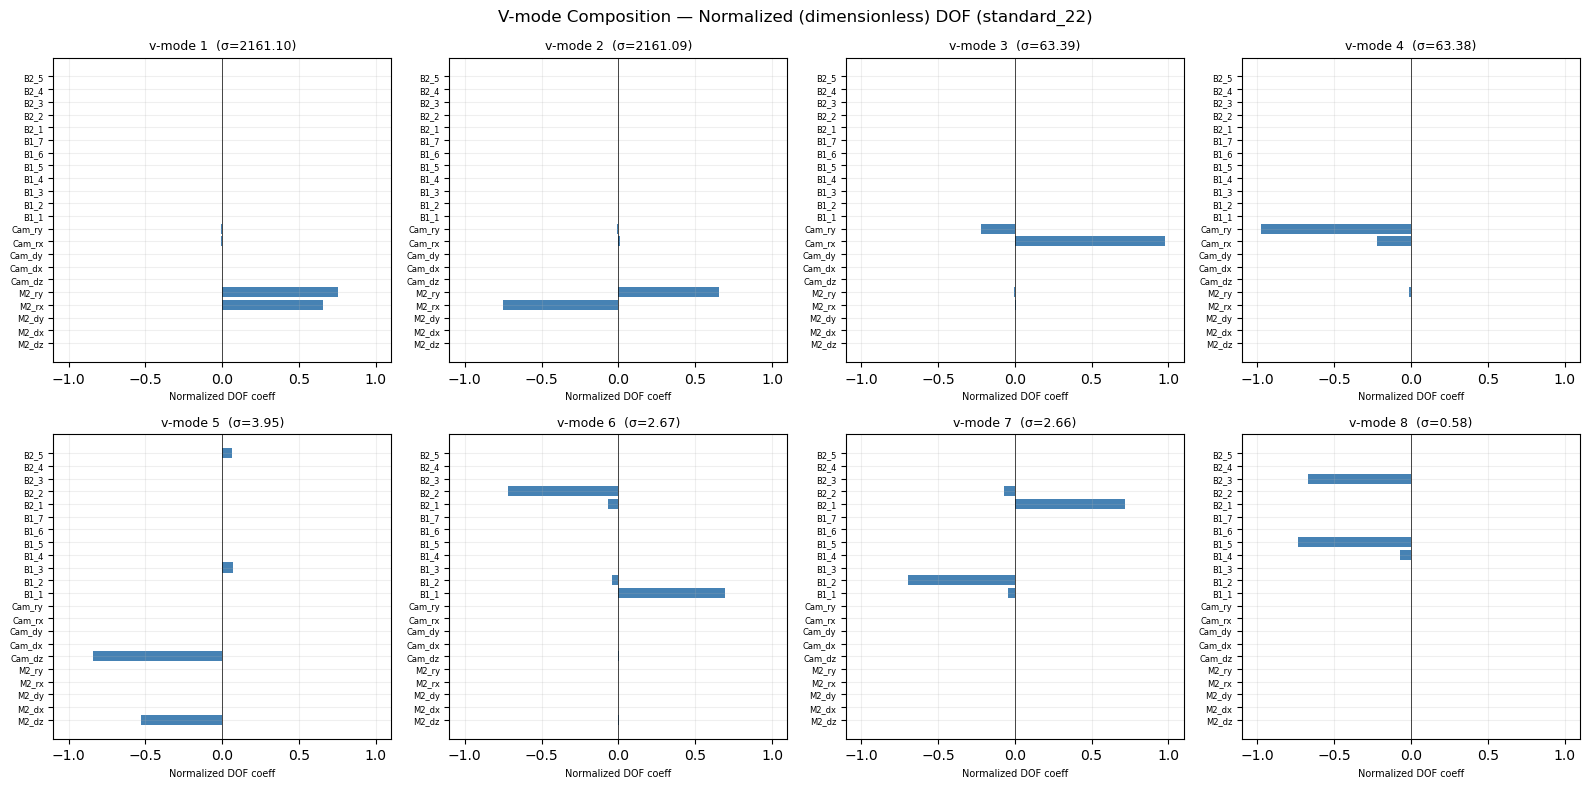

In [11]:
# Bar charts for the first 8 v-modes — Normalized (dimensionless) DOF coefficients
r = svd_results[default_dof_set]
V = r['V']
s = r['s']
labels_sub = r['labels']
n_show = min(8, V.shape[1])

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for k, ax in enumerate(axes.flat[:n_show]):
    ax.barh(range(len(labels_sub)), V[:, k], color='steelblue')
    ax.set_yticks(range(len(labels_sub)), labels_sub, fontsize=6)
    ax.set_title(f'v-mode {k+1}  (σ={s[k]:.2f})', fontsize=9)
    ax.axvline(0, color='k', lw=0.5)
    ax.set_xlim(-1.1, 1.1)
    ax.set_xlabel('Normalized DOF coeff', fontsize=7)
    ax.grid(alpha=0.2)

fig.suptitle(f'V-mode Composition — Normalized (dimensionless) DOF ({default_dof_set})', fontsize=12)
fig.tight_layout()
plt.show()

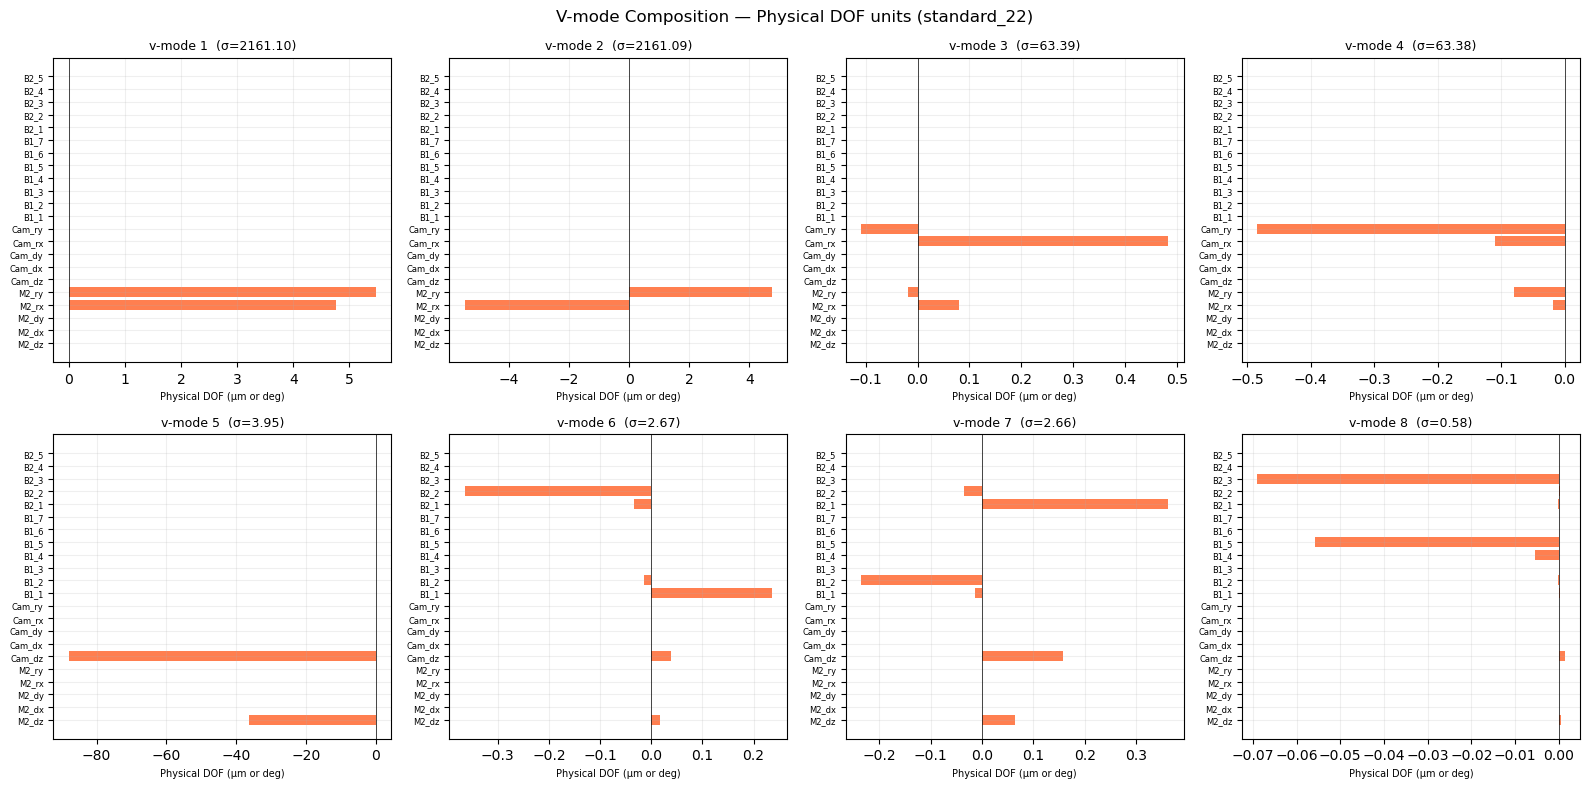

In [12]:
# Bar charts for the first 8 v-modes — Physical DOF coefficients (V_jk * n_j)
r = svd_results[default_dof_set]
V = r['V']
s = r['s']
labels_sub = r['labels']
n_sub = norm_vector[r['dof_indices']]
n_show = min(8, V.shape[1])

# Physical V: each column is V[:, k] * n_j (physical units per unit v-mode amplitude)
V_phys = V * n_sub[:, np.newaxis]

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for k, ax in enumerate(axes.flat[:n_show]):
    ax.barh(range(len(labels_sub)), V_phys[:, k], color='coral')
    ax.set_yticks(range(len(labels_sub)), labels_sub, fontsize=6)
    ax.set_title(f'v-mode {k+1}  (σ={s[k]:.2f})', fontsize=9)
    ax.axvline(0, color='k', lw=0.5)
    ax.set_xlabel('Physical DOF (µm or deg)', fontsize=7)
    ax.grid(alpha=0.2)

fig.suptitle(f'V-mode Composition — Physical DOF units ({default_dof_set})', fontsize=12)
fig.tight_layout()
plt.show()

### 3.2 Dominant DOF Contributors per V-Mode

In [13]:
r = svd_results[default_dof_set]
V = r['V']
labels_sub = r['labels']
n_trunc = n_modes_truncated[default_dof_set]

n_top = 4
print(f'Top {n_top} DOF contributors per v-mode ({default_dof_set}, {n_trunc} retained modes):')
print(f'{"v-mode":>6s} {"σ_k":>10s}   contributors (normalized DOF coefficients)')
for k in range(n_trunc):
    order = np.argsort(-np.abs(V[:, k]))
    parts = []
    for idx in order[:n_top]:
        coeff = V[idx, k]
        if np.abs(coeff) > 0.01:
            parts.append(f'{coeff:+.3f}*{labels_sub[idx]}')
    print(f'{k+1:>6d} {r["s"][k]:>10.4f}   {"  ".join(parts)}')

Top 4 DOF contributors per v-mode (standard_22, 12 retained modes):
v-mode        σ_k   contributors (normalized DOF coefficients)
     1  2161.1008   +0.754*M2_ry  +0.656*M2_rx
     2  2161.0939   -0.754*M2_rx  +0.656*M2_ry
     3    63.3856   +0.976*Cam_rx  -0.220*Cam_ry  +0.011*M2_rx
     4    63.3849   -0.976*Cam_ry  -0.220*Cam_rx  -0.011*M2_ry
     5     3.9518   -0.843*Cam_dz  -0.531*M2_dz  +0.068*B1_3  +0.061*B2_5
     6     2.6724   -0.717*B2_2  +0.693*B1_1  -0.067*B2_1  -0.041*B1_2
     7     2.6585   +0.717*B2_1  -0.693*B1_2  -0.067*B2_2  -0.042*B1_1
     8     0.5767   -0.736*B1_5  -0.673*B2_3  -0.073*B1_4
     9     0.5655   -0.741*B1_4  +0.667*B2_4  +0.073*B1_5
    10     0.1134   +1.000*B1_6  +0.011*B2_3  -0.011*B1_5
    11     0.1017   +1.000*B1_7
    12     0.0630   +0.657*B1_3  +0.534*B2_5  -0.405*M2_dz  +0.347*Cam_dz


<a id='Zernike Patterns' ></a>
## 4. V-Mode Wavefront Signatures

The wavefront pattern of v-mode k is given by the k-th column of U, reshaped to (n_wfs, n_zernike).
This shows which Zernike terms each v-mode excites at each WFS.

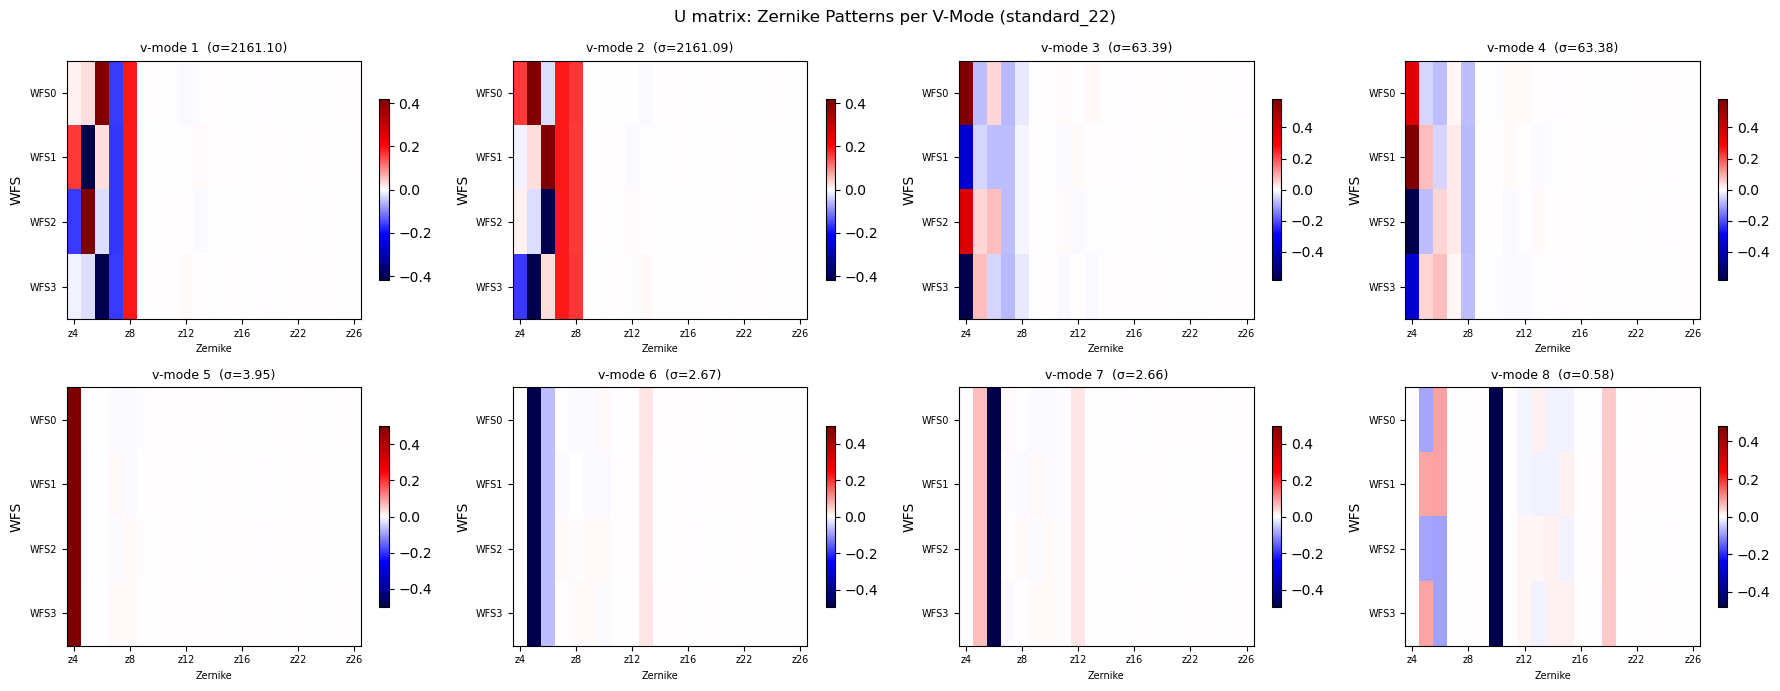

In [14]:
r = svd_results[default_dof_set]
U = r['U']
s = r['s']
n_show = min(8, U.shape[1])

fig, axes = plt.subplots(2, 4, figsize=(18, 7))
for k, ax in enumerate(axes.flat[:n_show]):
    # Reshape U column back to (n_wfs, n_zernike) — rows were concatenated as WFS0_Z, WFS1_Z, ...
    u_col = U[:, k].reshape(n_wfs, n_zernike)
    vmax = np.max(np.abs(u_col))
    im = ax.imshow(u_col, cmap='seismic', aspect='auto', vmin=-vmax, vmax=vmax)
    ax.set_title(f'v-mode {k+1}  (σ={s[k]:.2f})', fontsize=9)
    ax.set_ylabel('WFS')
    ax.set_yticks(range(n_wfs), [f'WFS{i}' for i in range(n_wfs)], fontsize=7)
    zern_ticks = range(0, n_zernike, 4)
    ax.set_xticks(list(zern_ticks), [f'z{zn[i]}' for i in zern_ticks], fontsize=7)
    ax.set_xlabel('Zernike', fontsize=7)
    fig.colorbar(im, ax=ax, shrink=0.7)

fig.suptitle(f'U matrix: Zernike Patterns per V-Mode ({default_dof_set})', fontsize=12)
fig.tight_layout()
plt.show()

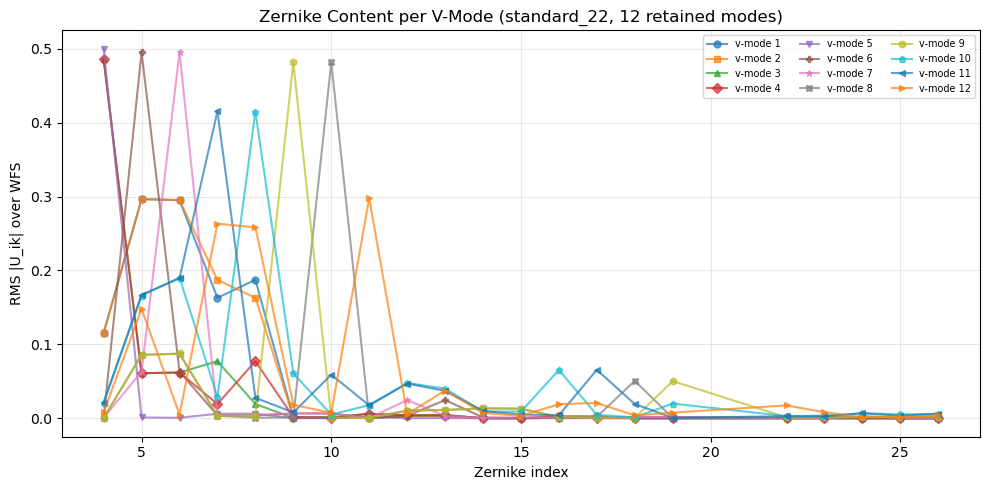

In [15]:
# Average Zernike power per v-mode (averaged over WFS) — distinct markers per mode
r = svd_results[default_dof_set]
U = r['U']
n_trunc = n_modes_truncated[default_dof_set]
n_show = min(n_trunc, U.shape[1])

fig, ax = plt.subplots(1, 1, figsize=(10, 5))
for k in range(n_show):
    u_col = U[:, k].reshape(n_wfs, n_zernike)
    # RMS over WFS for each Zernike
    zern_rms = np.sqrt(np.mean(u_col**2, axis=0))
    mk = marker_cycle[k % len(marker_cycle)]
    ax.plot(zn, zern_rms, f'{mk}-', markersize=5, label=f'v-mode {k+1}', alpha=0.7)

ax.set_xlabel('Zernike index')
ax.set_ylabel('RMS |U_ik| over WFS')
ax.set_title(f'Zernike Content per V-Mode ({default_dof_set}, {n_show} retained modes)')
ax.legend(fontsize=7, ncol=3)
ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()

<a id='Control Equations' ></a>
## 5. Control Equations

Given a measured Zernike vector **z**, compute:
1. V-mode amplitudes: **a = Uᵀ @ z**
2. Dimensionless DOF correction: **q = V @ Σ⁻¹ @ a = Ã⁺ @ z**
3. Physical DOF correction: **Δdof_j = n_j × q_j**

In [16]:
def vmode_amplitudes(z_measured, svd_result):
    """Compute v-mode amplitudes: a_k = U^T_k @ z_measured.
    
    Parameters
    ----------
    z_measured : array (n_z * n_wfs,)
        Concatenated Zernike measurements from all WFS.
    svd_result : dict
        Output of compute_svd().
    
    Returns
    -------
    a : array (n_modes,)
        V-mode amplitudes in microns of wavefront.
    """
    return svd_result['U'].T @ z_measured


def dimensionless_dof_correction(z_measured, svd_result, n_modes_use=None):
    """Compute dimensionless DOF correction: q = V @ Sigma^-1 @ U^T @ z.
    
    Parameters
    ----------
    z_measured : array (n_z * n_wfs,)
    svd_result : dict
    n_modes_use : int or None
        Number of modes to retain (truncation). None = all.
    
    Returns
    -------
    q : array (n_dof,)
        Dimensionless DOF corrections.
    """
    a = vmode_amplitudes(z_measured, svd_result)
    s = svd_result['s']
    V = svd_result['V']
    if n_modes_use is None:
        n_modes_use = len(s)
    q = V[:, :n_modes_use] @ (a[:n_modes_use] / s[:n_modes_use])
    return q


def physical_dof_correction(z_measured, svd_result, norm_vec, n_modes_use=None):
    """Compute physical DOF correction: delta_dof_j = n_j * q_j.
    
    Parameters
    ----------
    z_measured : array (n_z * n_wfs,)
    svd_result : dict
    norm_vec : array (n_dof_full,)
        Full normalization vector (50 entries).
    n_modes_use : int or None
    
    Returns
    -------
    delta_dof : array (n_dof,)
        Physical DOF corrections in microns or degrees.
    """
    q = dimensionless_dof_correction(z_measured, svd_result, n_modes_use)
    n_sub = norm_vec[svd_result['dof_indices']]
    return n_sub * q


print('Control equation functions defined.')

Control equation functions defined.


### 5.1 Example: Wavefront from a Single V-Mode Excitation

In [17]:
# Excite each v-mode by unit dimensionless amplitude and show the resulting Zernike pattern
r = svd_results[default_dof_set]
U = r['U']
s = r['s']
V = r['V']
Atilde_sub = r['Atilde_sub']
n_trunc = n_modes_truncated[default_dof_set]

print('Verify SVD reconstruction: ||Ã - U @ diag(s) @ V^T|| / ||Ã|| = ',
      np.linalg.norm(Atilde_sub - U @ np.diag(s) @ V.T) / np.linalg.norm(Atilde_sub))

# Zernike vector from unit v-mode k excitation: z = Ã @ v_k = U @ diag(s) @ e_k = s_k * U_k
print(f'\nWavefront RMS (microns) from unit dimensionless v-mode excitation ({n_trunc} retained modes):')
for k in range(n_trunc):
    z_from_vmode = s[k] * U[:, k]
    rms = np.sqrt(np.mean(z_from_vmode**2))
    print(f'  v-mode {k+1:2d}: σ_k={s[k]:8.4f}, wavefront RMS={rms:.4f} µm')

Verify SVD reconstruction: ||Ã - U @ diag(s) @ V^T|| / ||Ã|| =  1.4688972162279194e-15

Wavefront RMS (microns) from unit dimensionless v-mode excitation (12 retained modes):
  v-mode  1: σ_k=2161.1008, wavefront RMS=235.7954 µm
  v-mode  2: σ_k=2161.0939, wavefront RMS=235.7947 µm
  v-mode  3: σ_k= 63.3856, wavefront RMS=6.9159 µm
  v-mode  4: σ_k= 63.3849, wavefront RMS=6.9159 µm
  v-mode  5: σ_k=  3.9518, wavefront RMS=0.4312 µm
  v-mode  6: σ_k=  2.6724, wavefront RMS=0.2916 µm
  v-mode  7: σ_k=  2.6585, wavefront RMS=0.2901 µm
  v-mode  8: σ_k=  0.5767, wavefront RMS=0.0629 µm
  v-mode  9: σ_k=  0.5655, wavefront RMS=0.0617 µm
  v-mode 10: σ_k=  0.1134, wavefront RMS=0.0124 µm
  v-mode 11: σ_k=  0.1017, wavefront RMS=0.0111 µm
  v-mode 12: σ_k=  0.0630, wavefront RMS=0.0069 µm


### 5.2 Round-Trip Test: z → a → q → Δdof → z_reconstructed

Test the full control chain for two cases:
- **Case A**: 50 DOFs, all 50 v-modes (no truncation — perfect pseudoinverse)
- **Case B**: 22 DOFs, 12 retained v-modes (operational truncation)

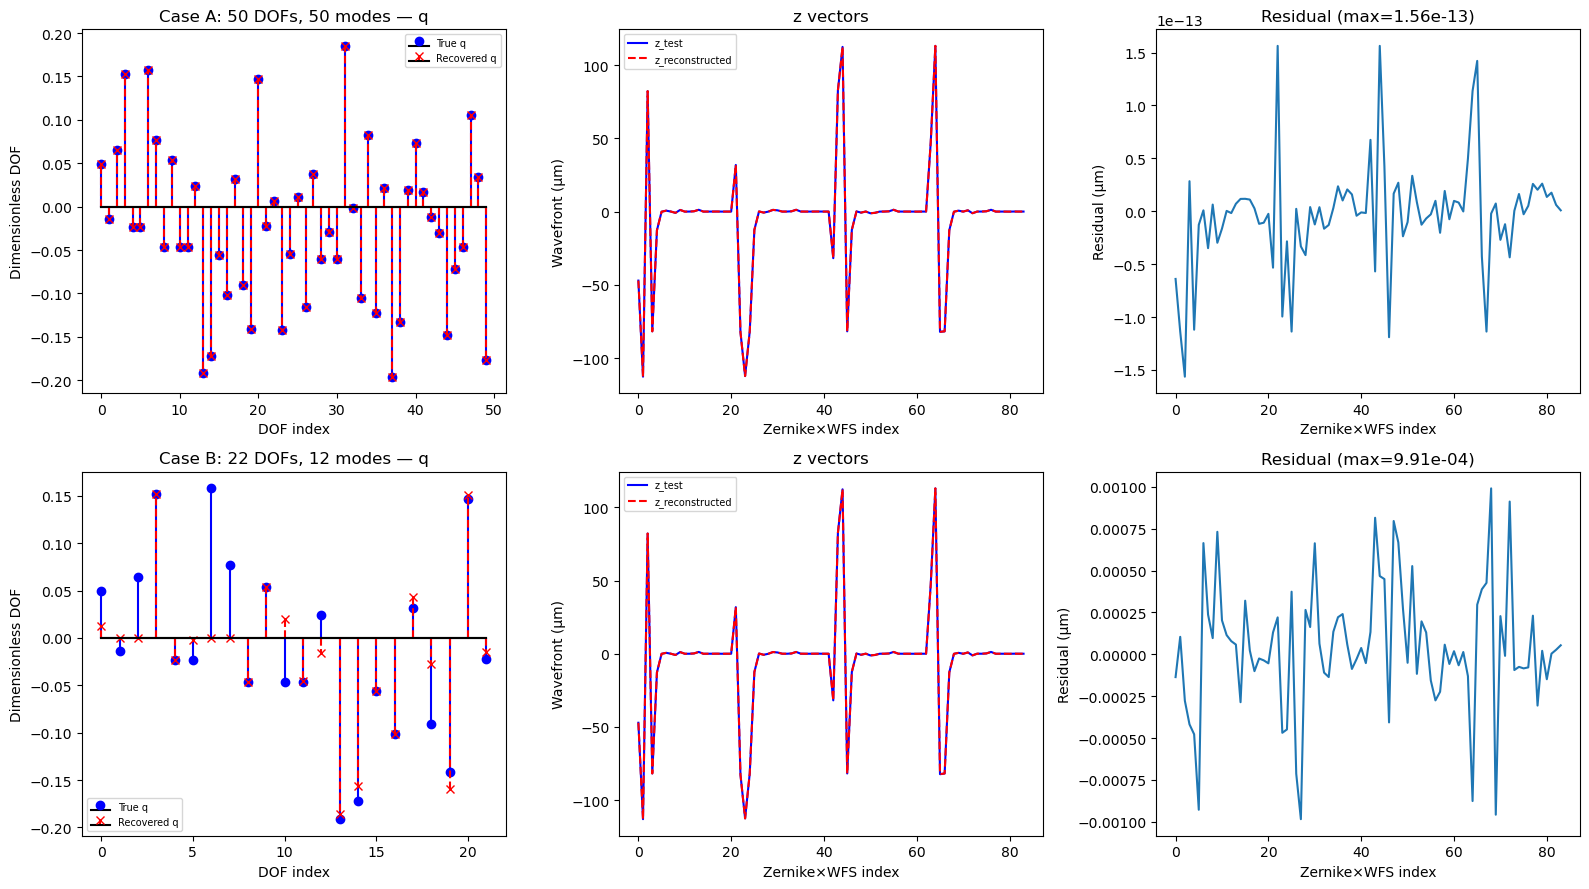

Case A (50 DOFs, 50 modes): DOF error = 2.45e-09,  z error = 1.41e-15
Case B (22 DOFs, 12 modes): DOF error = 4.85e-01,  z error = 1.06e-05

Case B has nonzero error because 10 of 22 v-modes are truncated.


In [18]:
def run_roundtrip_test(dof_set_name, n_modes_use, seed=42):
    """Run a round-trip test: generate z from known q, recover q, reconstruct z."""
    r = svd_results[dof_set_name]
    V = r['V']
    s = r['s']
    Atilde_sub = r['Atilde_sub']
    n_dof = len(r['dof_indices'])
    
    # Create a test Zernike vector from a known DOF perturbation
    np.random.seed(seed)
    q_true = np.random.randn(n_dof) * 0.1
    z_test = Atilde_sub @ q_true
    
    # Recover DOFs via truncated pseudoinverse
    q_recovered = dimensionless_dof_correction(z_test, r, n_modes_use=n_modes_use)
    
    # Reconstruct Zernike from recovered DOFs
    z_reconstructed = Atilde_sub @ q_recovered
    residual = z_test - z_reconstructed
    
    dof_err = np.linalg.norm(q_true - q_recovered) / np.linalg.norm(q_true)
    z_err = np.linalg.norm(residual) / np.linalg.norm(z_test)
    
    return q_true, q_recovered, z_test, z_reconstructed, residual, dof_err, z_err

# --- Case A: 50 DOFs, all 50 v-modes ---
q_true_A, q_rec_A, z_A, z_rec_A, res_A, dof_err_A, z_err_A = run_roundtrip_test('all_50', n_modes_use=50)

# --- Case B: 22 DOFs, 12 v-modes ---
q_true_B, q_rec_B, z_B, z_rec_B, res_B, dof_err_B, z_err_B = run_roundtrip_test('standard_22', n_modes_use=12)

fig, axes = plt.subplots(2, 3, figsize=(16, 9))

# Case A: top row
axes[0, 0].stem(q_true_A, linefmt='b-', markerfmt='bo', basefmt='k-', label='True q')
axes[0, 0].stem(q_rec_A, linefmt='r--', markerfmt='rx', basefmt='k-', label='Recovered q')
axes[0, 0].set_xlabel('DOF index')
axes[0, 0].set_ylabel('Dimensionless DOF')
axes[0, 0].set_title(f'Case A: 50 DOFs, 50 modes — q')
axes[0, 0].legend(fontsize=7)

axes[0, 1].plot(z_A, 'b-', label='z_test')
axes[0, 1].plot(z_rec_A, 'r--', label='z_reconstructed')
axes[0, 1].set_xlabel('Zernike×WFS index')
axes[0, 1].set_ylabel('Wavefront (µm)')
axes[0, 1].set_title('z vectors')
axes[0, 1].legend(fontsize=7)

axes[0, 2].plot(res_A)
axes[0, 2].set_xlabel('Zernike×WFS index')
axes[0, 2].set_ylabel('Residual (µm)')
axes[0, 2].set_title(f'Residual (max={np.max(np.abs(res_A)):.2e})')

# Case B: bottom row
axes[1, 0].stem(q_true_B, linefmt='b-', markerfmt='bo', basefmt='k-', label='True q')
axes[1, 0].stem(q_rec_B, linefmt='r--', markerfmt='rx', basefmt='k-', label='Recovered q')
axes[1, 0].set_xlabel('DOF index')
axes[1, 0].set_ylabel('Dimensionless DOF')
axes[1, 0].set_title(f'Case B: 22 DOFs, 12 modes — q')
axes[1, 0].legend(fontsize=7)

axes[1, 1].plot(z_B, 'b-', label='z_test')
axes[1, 1].plot(z_rec_B, 'r--', label='z_reconstructed')
axes[1, 1].set_xlabel('Zernike×WFS index')
axes[1, 1].set_ylabel('Wavefront (µm)')
axes[1, 1].set_title('z vectors')
axes[1, 1].legend(fontsize=7)

axes[1, 2].plot(res_B)
axes[1, 2].set_xlabel('Zernike×WFS index')
axes[1, 2].set_ylabel('Residual (µm)')
axes[1, 2].set_title(f'Residual (max={np.max(np.abs(res_B)):.2e})')

fig.tight_layout()
plt.show()

print(f'Case A (50 DOFs, 50 modes): DOF error = {dof_err_A:.2e},  z error = {z_err_A:.2e}')
print(f'Case B (22 DOFs, 12 modes): DOF error = {dof_err_B:.2e},  z error = {z_err_B:.2e}')
print(f'\nCase B has nonzero error because 10 of 22 v-modes are truncated.')

<a id='Noise Amplification' ></a>
## 6. Noise Amplification and Information Content

A mode with small σ_k amplifies measurement noise: the DOF correction scales as a_k / σ_k.
If measurement noise is σ_noise in each Zernike, the DOF noise in mode k scales as σ_noise / σ_k.

This section quantifies the noise amplification (1/σ_k), the effective condition number,
and the information content vs. truncation level.

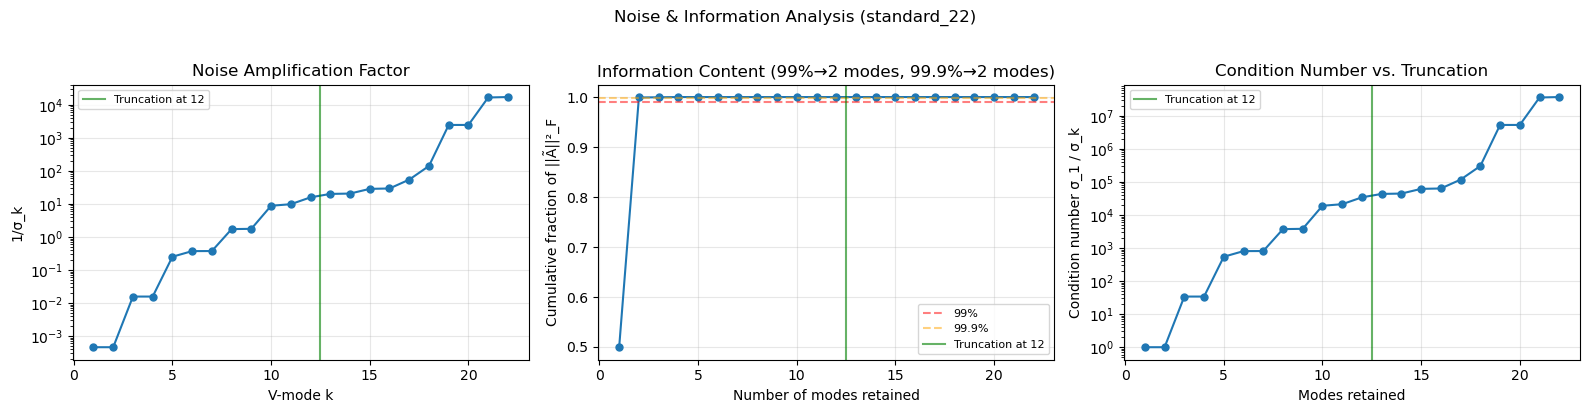

In [19]:
r = svd_results[default_dof_set]
s = r['s']
n_trunc = n_modes_truncated[default_dof_set]

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# 1/sigma_k: noise amplification factor (1-indexed)
axes[0].semilogy(np.arange(1, len(s) + 1), 1.0 / s, 'o-', markersize=5)
axes[0].axvline(n_trunc + 0.5, color='green', ls='-', alpha=0.6, label=f'Truncation at {n_trunc}')
axes[0].set_xlabel('V-mode k')
axes[0].set_ylabel('1/σ_k')
axes[0].set_title('Noise Amplification Factor')
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.3)

# Cumulative fraction of ||Ã||_F^2 captured (1-indexed)
s2_cumsum = np.cumsum(s**2)
s2_total = np.sum(s**2)
frac = s2_cumsum / s2_total
axes[1].plot(np.arange(1, len(s) + 1), frac, 'o-', markersize=5)
axes[1].axhline(0.99, color='red', ls='--', alpha=0.5, label='99%')
axes[1].axhline(0.999, color='orange', ls='--', alpha=0.5, label='99.9%')
axes[1].axvline(n_trunc + 0.5, color='green', ls='-', alpha=0.6, label=f'Truncation at {n_trunc}')
n99 = np.searchsorted(frac, 0.99) + 1
n999 = np.searchsorted(frac, 0.999) + 1
axes[1].set_xlabel('Number of modes retained')
axes[1].set_ylabel('Cumulative fraction of ||Ã||²_F')
axes[1].set_title(f'Information Content (99%→{n99} modes, 99.9%→{n999} modes)')
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.3)

# Effective condition number vs. truncation level (1-indexed)
cond = [s[0] / s[k] for k in range(len(s))]
axes[2].semilogy(range(1, len(s) + 1), cond, 'o-', markersize=5)
axes[2].axvline(n_trunc + 0.5, color='green', ls='-', alpha=0.6, label=f'Truncation at {n_trunc}')
axes[2].set_xlabel('Modes retained')
axes[2].set_ylabel('Condition number σ_1 / σ_k')
axes[2].set_title('Condition Number vs. Truncation')
axes[2].legend(fontsize=8)
axes[2].grid(alpha=0.3)

fig.suptitle(f'Noise & Information Analysis ({default_dof_set})', fontsize=12, y=1.02)
fig.tight_layout()
plt.show()

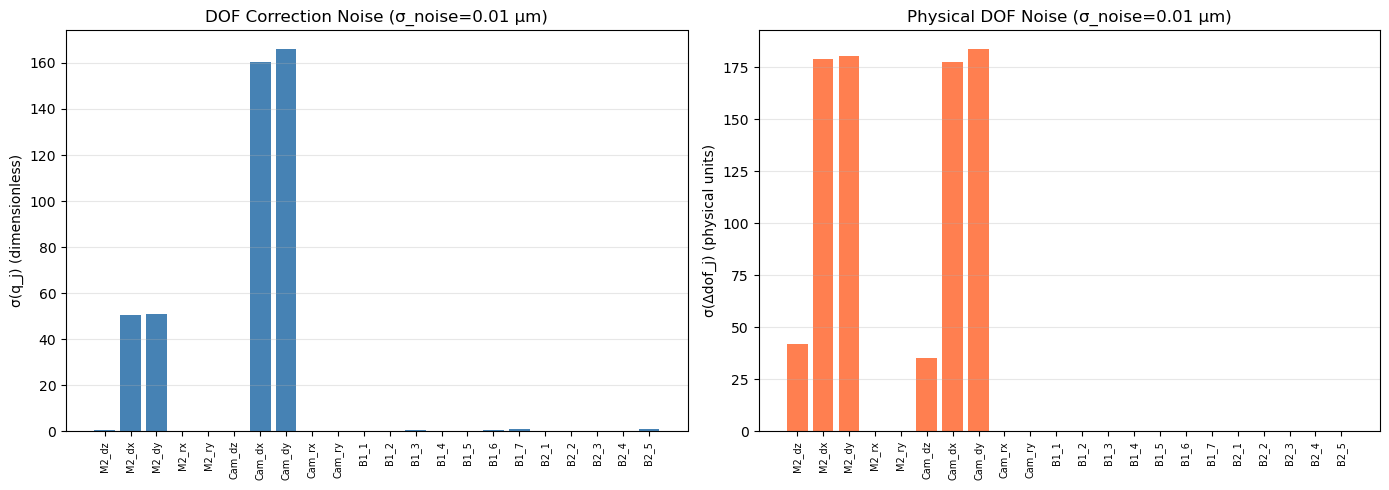

In [20]:
# Simulate DOF correction noise for given measurement noise level
sigma_noise_um = 0.01  # microns of wavefront noise per Zernike per WFS

r = svd_results[default_dof_set]
s = r['s']
V = r['V']
n_dof_sub = len(r['dof_indices'])
n_meas = n_zernike * n_wfs
labels_sub = r['labels']

# Analytic: variance in q_j from white noise in z
# q = V @ Sigma^-1 @ U^T @ z, so Cov(q) = sigma^2 * V @ Sigma^-2 @ V^T
Sigma_inv2 = np.diag(1.0 / s**2)
Cov_q = sigma_noise_um**2 * V @ Sigma_inv2 @ V.T
sigma_q = np.sqrt(np.diag(Cov_q))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(range(n_dof_sub), sigma_q, color='steelblue')
axes[0].set_xticks(range(n_dof_sub), labels_sub, rotation=90, fontsize=7)
axes[0].set_ylabel('σ(q_j) (dimensionless)')
axes[0].set_title(f'DOF Correction Noise (σ_noise={sigma_noise_um} µm)')
axes[0].grid(alpha=0.3, axis='y')

# Physical DOF noise
n_sub = norm_vector[r['dof_indices']]
sigma_phys = n_sub * sigma_q
axes[1].bar(range(n_dof_sub), sigma_phys, color='coral')
axes[1].set_xticks(range(n_dof_sub), labels_sub, rotation=90, fontsize=7)
axes[1].set_ylabel('σ(Δdof_j) (physical units)')
axes[1].set_title(f'Physical DOF Noise (σ_noise={sigma_noise_um} µm)')
axes[1].grid(alpha=0.3, axis='y')

fig.tight_layout()
plt.show()

### 6.1 Effect of Truncation on Noise vs. Reconstruction Error

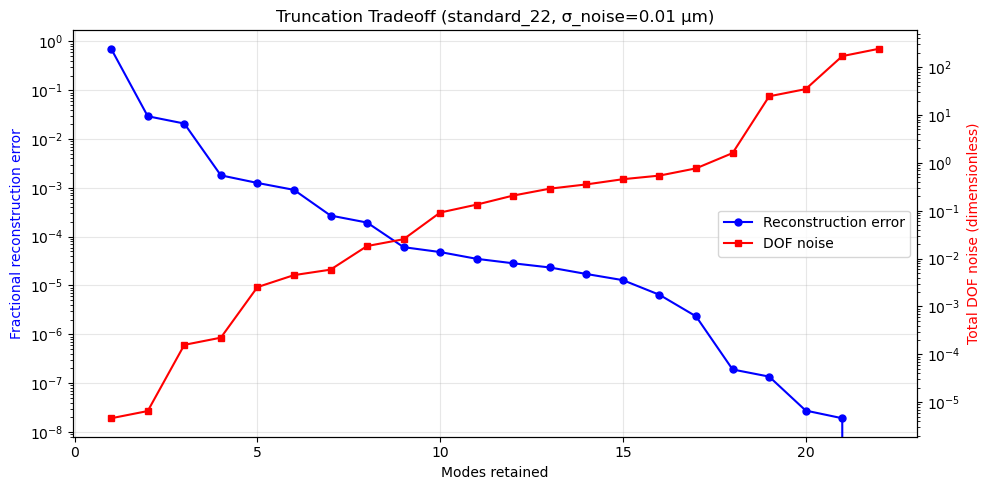

In [21]:
r = svd_results[default_dof_set]
s = r['s']
Atilde_sub = r['Atilde_sub']
n_modes_total = len(s)

sigma_noise_um = 0.01

# For each truncation level, compute:
# 1. Reconstruction error: ||Ã - Ã_trunc||_F / ||Ã||_F
# 2. Total DOF noise: sqrt(sum(sigma_q_j^2))
recon_error = []
total_dof_noise = []

for n_keep in range(1, n_modes_total + 1):
    # Truncated reconstruction
    s_trunc = s.copy()
    s_trunc[n_keep:] = 0
    residual_frac = np.sqrt(np.sum(s[n_keep:]**2)) / np.sqrt(np.sum(s**2))
    recon_error.append(residual_frac)
    
    # DOF noise from retained modes
    noise_var = sigma_noise_um**2 * np.sum(1.0 / s[:n_keep]**2)
    total_dof_noise.append(np.sqrt(noise_var))

fig, ax1 = plt.subplots(figsize=(10, 5))
ax2 = ax1.twinx()

ax1.semilogy(range(1, n_modes_total + 1), recon_error, 'bo-', markersize=5, label='Reconstruction error')
ax2.semilogy(range(1, n_modes_total + 1), total_dof_noise, 'rs-', markersize=5, label='DOF noise')

ax1.set_xlabel('Modes retained')
ax1.set_ylabel('Fractional reconstruction error', color='blue')
ax2.set_ylabel('Total DOF noise (dimensionless)', color='red')
ax1.set_title(f'Truncation Tradeoff ({default_dof_set}, σ_noise={sigma_noise_um} µm)')
ax1.grid(alpha=0.3)

lines1, lab1 = ax1.get_legend_handles_labels()
lines2, lab2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, lab1 + lab2, loc='center right')

fig.tight_layout()
plt.show()

<a id='Control Gain' ></a>
## 7. Control Gain Analysis

With a proportional controller K_P applied uniformly in v-mode space:
- Effective loop gain for mode k = K_P × σ_k
- Stability requires K_P × σ_k < 1 for all retained modes

Per-mode gain scheduling: K_P(k) = gain_factor / σ_k equalizes all loop gains.

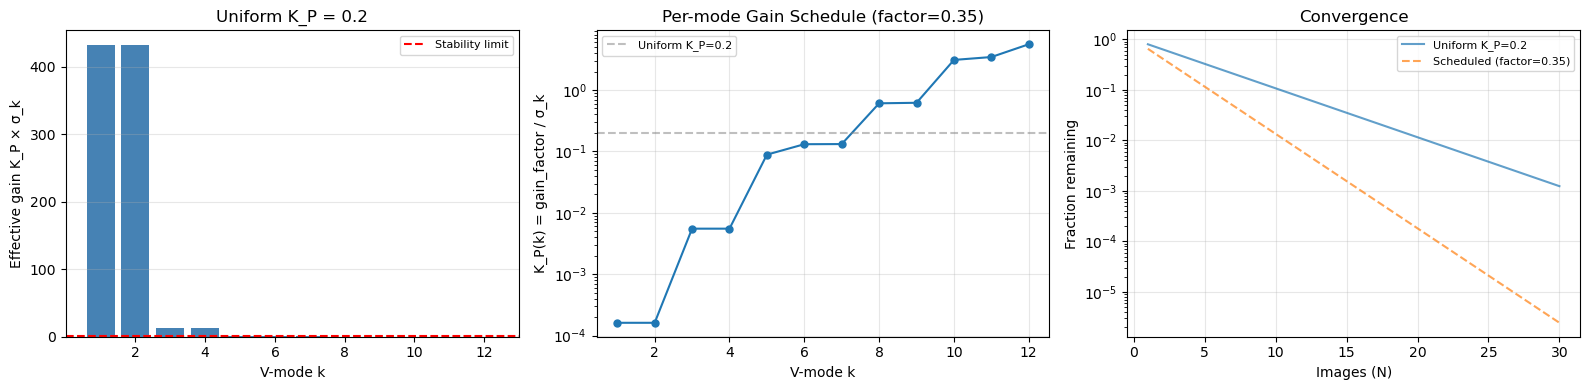

In [22]:
r = svd_results[default_dof_set]
s = r['s']
n_trunc = n_modes_truncated[default_dof_set]

# Uniform gain
K_P_uniform = 0.2
effective_gain_uniform = K_P_uniform * s[:n_trunc]

# Per-mode gain scheduling
gain_factor = 0.35
K_P_per_mode = gain_factor / s[:n_trunc]

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Effective gain: uniform (1-indexed)
axes[0].bar(np.arange(1, n_trunc + 1), effective_gain_uniform, color='steelblue')
axes[0].axhline(1.0, color='red', ls='--', label='Stability limit')
axes[0].set_xlabel('V-mode k')
axes[0].set_ylabel('Effective gain K_P × σ_k')
axes[0].set_title(f'Uniform K_P = {K_P_uniform}')
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.3, axis='y')

# Per-mode K_P values (1-indexed)
axes[1].semilogy(np.arange(1, n_trunc + 1), K_P_per_mode, 'o-', markersize=5)
axes[1].axhline(K_P_uniform, color='gray', ls='--', alpha=0.5, label=f'Uniform K_P={K_P_uniform}')
axes[1].set_xlabel('V-mode k')
axes[1].set_ylabel('K_P(k) = gain_factor / σ_k')
axes[1].set_title(f'Per-mode Gain Schedule (factor={gain_factor})')
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.3)

# Convergence comparison
N = np.arange(1, 31)
pole_uniform = 1.0 - K_P_uniform
residual = pole_uniform**N
axes[2].plot(N, residual, '-', label=f'Uniform K_P={K_P_uniform}', alpha=0.7)

pole_sched = 1.0 - gain_factor
residual_sched = pole_sched**N
axes[2].plot(N, residual_sched, '--', label=f'Scheduled (factor={gain_factor})', alpha=0.7)

axes[2].set_xlabel('Images (N)')
axes[2].set_ylabel('Fraction remaining')
axes[2].set_title('Convergence')
axes[2].set_yscale('log')
axes[2].legend(fontsize=8)
axes[2].grid(alpha=0.3)

fig.tight_layout()
plt.show()

### 7.1 Per-Mode Convergence with 2-Step Delay

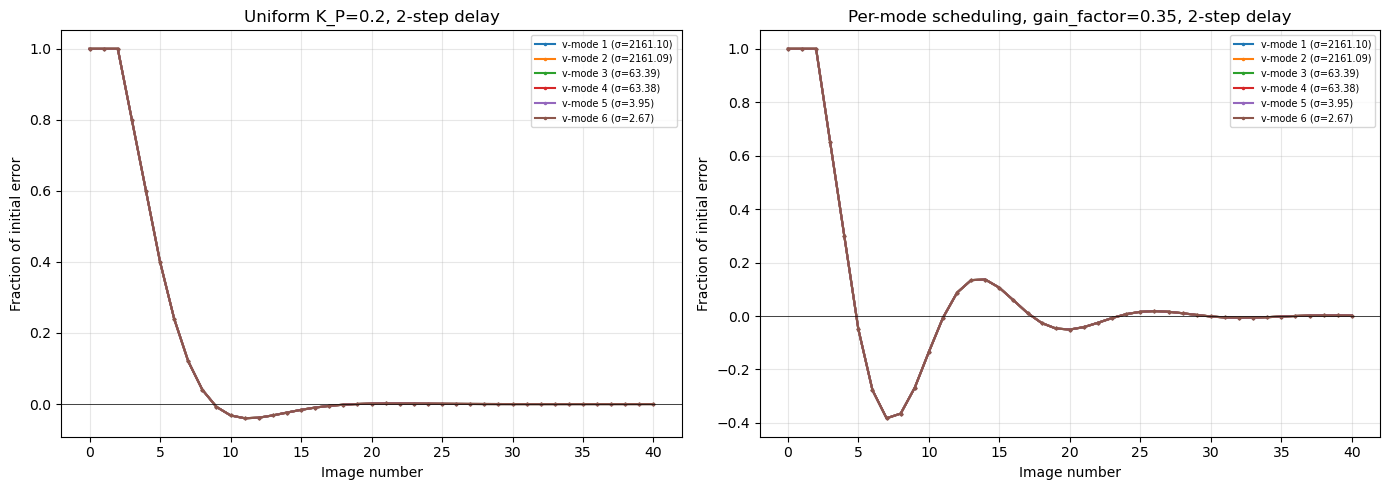

In [23]:
# Simulate the discrete control loop with 2-step delay for each v-mode independently
# a_k[n+1] = a_k[n] - K_P * a_k[n - delay]

r = svd_results[default_dof_set]
s = r['s']
n_trunc = n_modes_truncated[default_dof_set]
n_images = 40
delay = 2  # correction from image n applied before image n+3

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Uniform gain
K_P = 0.2
for k in range(min(6, n_trunc)):
    x = np.zeros(n_images + delay + 1)
    x[0] = 1.0
    for n in range(n_images):
        if n + 1 <= delay:
            x[n + 1] = x[n]
        else:
            x[n + 1] = x[n] - K_P * x[n - delay]
    axes[0].plot(range(n_images + 1), x[:n_images + 1], '.-', markersize=3,
                 label=f'v-mode {k+1} (σ={s[k]:.2f})')

axes[0].set_xlabel('Image number')
axes[0].set_ylabel('Fraction of initial error')
axes[0].set_title(f'Uniform K_P={K_P}, {delay}-step delay')
axes[0].legend(fontsize=7)
axes[0].grid(alpha=0.3)
axes[0].axhline(0, color='k', lw=0.5)

# Per-mode gain scheduling: a_k[n+1] = a_k[n] - gain_factor * a_k[n-delay]
gain_factor = 0.35
for k in range(min(6, n_trunc)):
    x = np.zeros(n_images + delay + 1)
    x[0] = 1.0
    for n in range(n_images):
        if n + 1 <= delay:
            x[n + 1] = x[n]
        else:
            x[n + 1] = x[n] - gain_factor * x[n - delay]
    axes[1].plot(range(n_images + 1), x[:n_images + 1], '.-', markersize=3,
                 label=f'v-mode {k+1} (σ={s[k]:.2f})')

axes[1].set_xlabel('Image number')
axes[1].set_ylabel('Fraction of initial error')
axes[1].set_title(f'Per-mode scheduling, gain_factor={gain_factor}, {delay}-step delay')
axes[1].legend(fontsize=7)
axes[1].grid(alpha=0.3)
axes[1].axhline(0, color='k', lw=0.5)

fig.tight_layout()
plt.show()

<a id='DOF Set Comparison' ></a>
## 8. Comparison Across DOF Sets

Compare SVD properties for different DOF subsets (10, 22, 30, 50 DOFs).

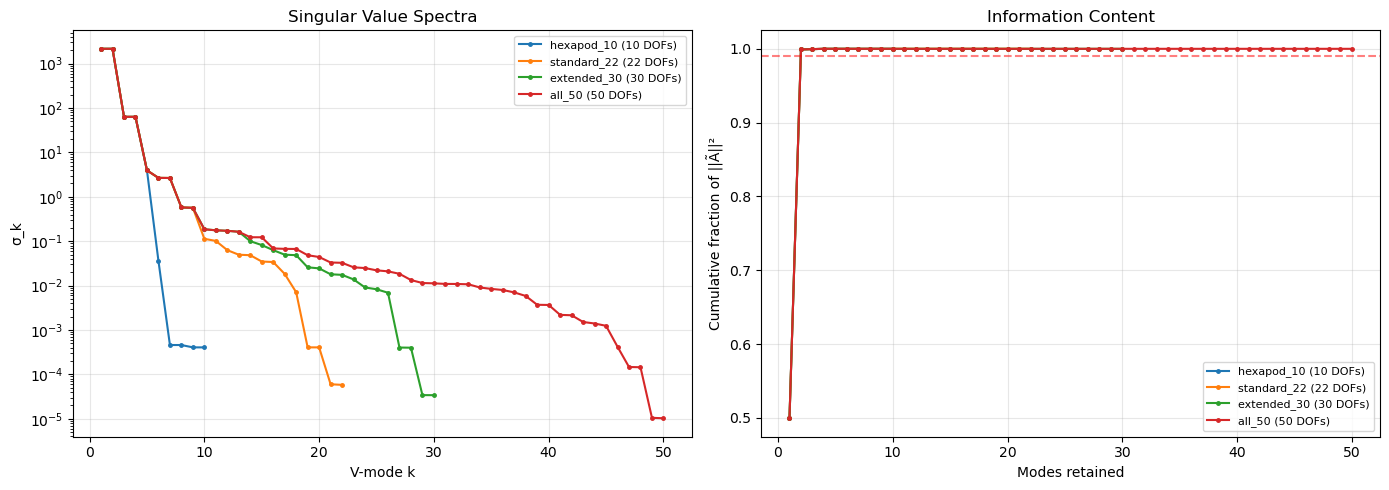

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for name, r in svd_results.items():
    s = r['s']
    n = len(s)
    axes[0].semilogy(np.arange(1, n + 1), s, '.-', markersize=5, label=f'{name} ({n} DOFs)')
    
    s2_cumsum = np.cumsum(s**2)
    axes[1].plot(np.arange(1, n + 1), s2_cumsum / s2_cumsum[-1], '.-', markersize=5,
                 label=f'{name} ({n} DOFs)')

axes[0].set_xlabel('V-mode k')
axes[0].set_ylabel('σ_k')
axes[0].set_title('Singular Value Spectra')
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.3)

axes[1].axhline(0.99, color='red', ls='--', alpha=0.5)
axes[1].set_xlabel('Modes retained')
axes[1].set_ylabel('Cumulative fraction of ||Ã||²')
axes[1].set_title('Information Content')
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.3)

fig.tight_layout()
plt.show()

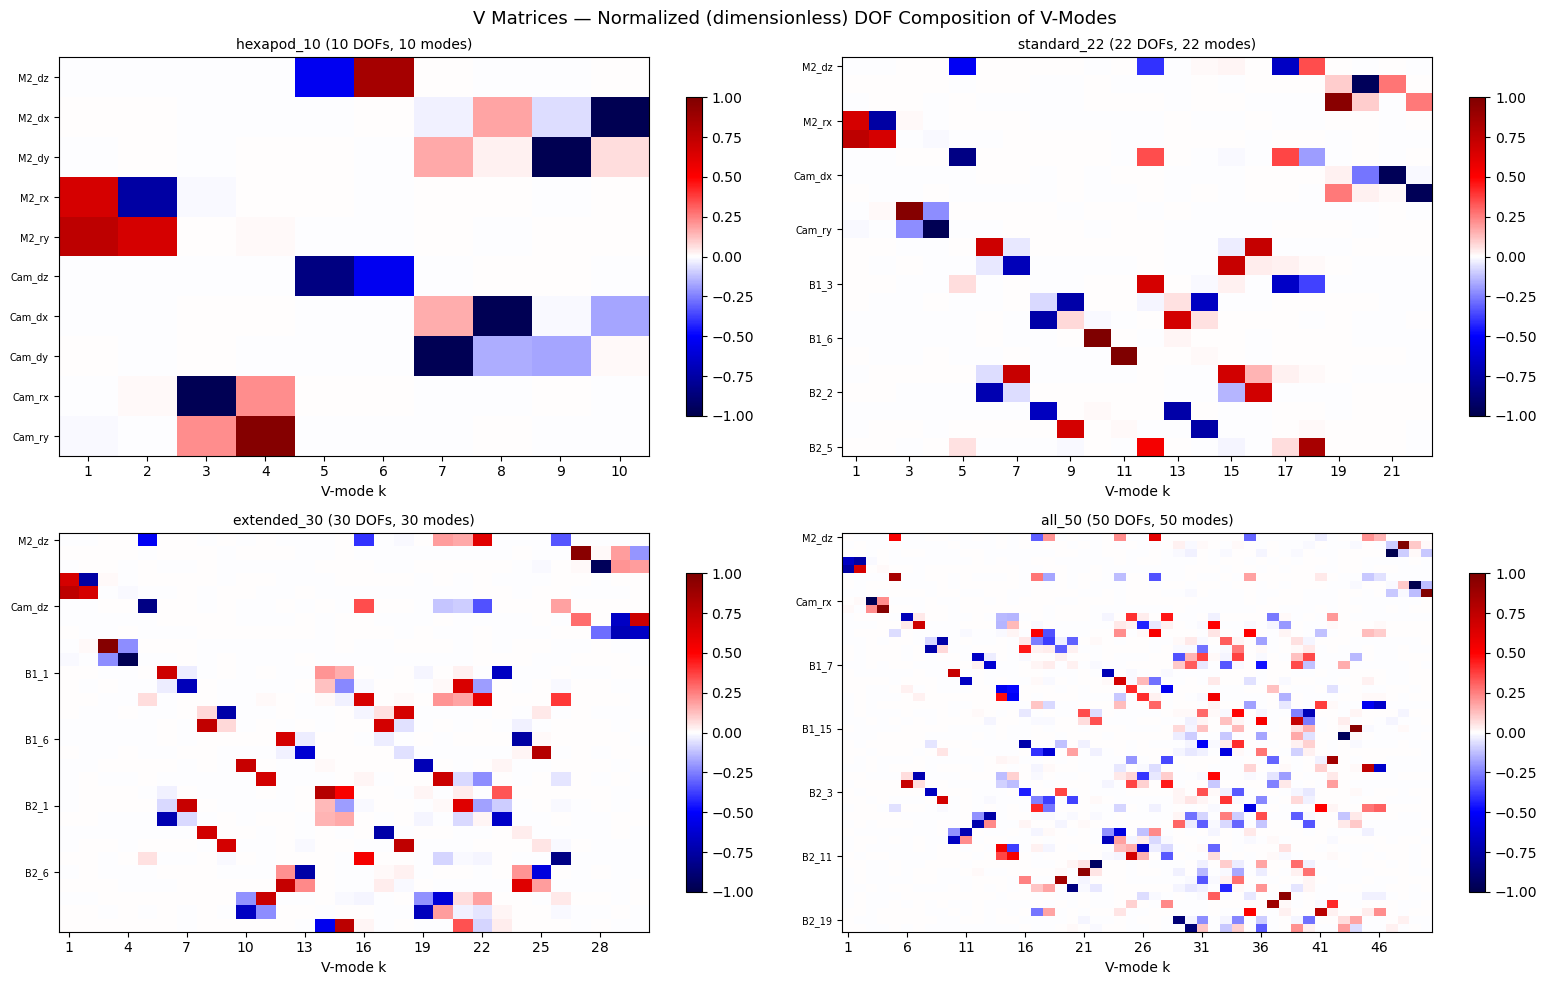

In [25]:
# V-matrix heatmaps for all DOF sets (1-indexed)
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

for ax, (name, r) in zip(axes.flat, svd_results.items()):
    V = r['V']
    labels_sub = r['labels']
    n_dof = len(labels_sub)
    n_modes = V.shape[1]
    im = ax.imshow(V, cmap='seismic', vmin=-1, vmax=1, aspect='auto')
    ax.set_title(f'{name} ({n_dof} DOFs, {n_modes} modes)', fontsize=10)
    ax.set_xlabel('V-mode k')
    xt = np.arange(0, n_modes, max(1, n_modes // 10))
    ax.set_xticks(xt, [str(x + 1) for x in xt])
    yt = range(0, n_dof, max(1, n_dof // 6))
    ax.set_yticks(list(yt), [labels_sub[i] for i in yt], fontsize=7)
    fig.colorbar(im, ax=ax, shrink=0.8)

fig.suptitle('V Matrices — Normalized (dimensionless) DOF Composition of V-Modes', fontsize=13)
fig.tight_layout()
plt.show()

<a id='Summary' ></a>
## 9. Summary Table

In [26]:
print(f'{"DOF Set":>15s} {"n_DOF":>6s} {"n_trunc":>7s} {"σ_max":>10s} {"σ_min":>10s} '
      f'{"Cond #":>10s} {"99% modes":>10s} {"99.9% modes":>12s}')
print('-' * 90)

for name, r in svd_results.items():
    s = r['s']
    n_trunc = n_modes_truncated[name]
    frac = np.cumsum(s**2) / np.sum(s**2)
    n99 = np.searchsorted(frac, 0.99) + 1
    n999 = np.searchsorted(frac, 0.999) + 1
    print(f'{name:>15s} {len(r["dof_indices"]):>6d} {n_trunc:>7d} {s[0]:>10.3f} {s[-1]:>10.2e} '
          f'{s[0]/s[-1]:>10.1f} {n99:>10d} {n999:>12d}')

        DOF Set  n_DOF n_trunc      σ_max      σ_min     Cond #  99% modes  99.9% modes
------------------------------------------------------------------------------------------
     hexapod_10     10      10   2161.101   4.07e-04  5315203.5          2            2
    standard_22     22      12   2161.101   5.82e-05 37125498.6          2            2
    extended_30     30      12   2161.101   3.41e-05 63382866.1          2            2
         all_50     50      12   2161.101   1.03e-05 209774716.2          2            2


<a id='Double-Zernike' ></a>
## 10. Double-Zernike V-Mode Decomposition

The double-Zernike basis describes wavefront patterns that are Zernike polynomial j over the pupil 
and Zernike polynomial k over the focal plane (Noll convention).

The focal plane positions are the 4 WFS corners. We use:
- **k_fp = 1** (constant over focal plane): field-averaged aberration
- **k_fp = 2** (x-tilt over focal plane): x-gradient of aberration
- **k_fp = 3** (y-tilt over focal plane): y-gradient of aberration

For each double-Zernike term (j, k_fp), we find:
1. Which v-modes are needed to produce this pattern
2. Whether the correction is "clean" (no crosstalk to other double-Zernike terms)

Analysis range: j = 4–11 for k_fp = 1; j = 4–8 for k_fp = 2, 3.

In [27]:
# --- Build the double-Zernike basis vectors ---
# Measurement vector layout: index i = wfs_idx * n_zernike + zern_local_idx
# where zern_local_idx indexes into our selected zn array (0..n_zernike-1)

# Focal plane Zernike polynomials evaluated at 4 WFS positions
# WFS positions (field angles in degrees)
wfs_xy = np.array(field_angles)  # shape (4, 2)
print('WFS focal plane positions (deg):')
for i, (x, y) in enumerate(wfs_xy):
    print(f'  WFS{i}: ({x:.4f}, {y:.4f})')

# Normalize positions to unit circle radius = max distance from center
R_fp = np.max(np.sqrt(wfs_xy[:, 0]**2 + wfs_xy[:, 1]**2))
wfs_x_norm = wfs_xy[:, 0] / R_fp
wfs_y_norm = wfs_xy[:, 1] / R_fp
print(f'\nNormalization radius R_fp = {R_fp:.4f} deg')
print(f'Normalized WFS positions: x = {wfs_x_norm}, y = {wfs_y_norm}')

# Focal plane Zernike values (Noll convention):
# k_fp=1: Z_1 = 1 (piston/constant)
# k_fp=2: Z_2 = 2*x (tilt-x)
# k_fp=3: Z_3 = 2*y (tilt-y)
fp_zernike = {
    1: np.ones(n_wfs),                  # constant
    2: 2.0 * wfs_x_norm,               # x-tilt
    3: 2.0 * wfs_y_norm,               # y-tilt
}

fp_zernike_names = {1: 'const', 2: 'x-tilt', 3: 'y-tilt'}

print('\nFocal plane Zernike values at WFS positions:')
for kfp, vals in fp_zernike.items():
    print(f'  k_fp={kfp} ({fp_zernike_names[kfp]}): {vals}')

# Build double-Zernike basis vectors
# dz_vector(j, k_fp) has length n_wfs * n_zernike
# Component at index (s * n_zernike + p) = delta(zn[p], j) * Z_{k_fp}(wfs_s)
def make_dz_vector(j_noll, k_fp):
    """Create a double-Zernike basis vector for pupil Zernike j and focal plane Zernike k_fp."""
    vec = np.zeros(n_wfs * n_zernike)
    # Find the local index of j_noll in our zn array
    match = np.where(zn == j_noll)[0]
    if len(match) == 0:
        return None  # j_noll not in our Zernike selection
    p = match[0]  # local index
    fp_vals = fp_zernike[k_fp]
    for s in range(n_wfs):
        vec[s * n_zernike + p] = fp_vals[s]
    return vec

# Define the double-Zernike terms to analyze
dz_terms = []
# j = 4-11 for k_fp = 1
for j in range(4, 12):
    dz_terms.append((j, 1))
# j = 4-8 for k_fp = 2 and 3
for j in range(4, 9):
    dz_terms.append((j, 2))
for j in range(4, 9):
    dz_terms.append((j, 3))

print(f'\n{len(dz_terms)} double-Zernike terms to analyze:')
for j, kfp in dz_terms:
    print(f'  (j={j}, k_fp={kfp}) = z{j} × {fp_zernike_names[kfp]}')

# Build all DZ basis vectors
dz_vectors = {}
for j, kfp in dz_terms:
    vec = make_dz_vector(j, kfp)
    if vec is not None:
        dz_vectors[(j, kfp)] = vec
    else:
        print(f'  WARNING: z{j} not in Zernike selection, skipping (j={j}, k_fp={kfp})')

print(f'\nBuilt {len(dz_vectors)} double-Zernike basis vectors')

WFS focal plane positions (deg):
  WFS0: (-1.1903, -1.1903)
  WFS1: (-1.1903, 1.1903)
  WFS2: (1.1903, -1.1903)
  WFS3: (1.1903, 1.1903)

Normalization radius R_fp = 1.6833 deg
Normalized WFS positions: x = [-0.70710678 -0.70710678  0.70710678  0.70710678], y = [-0.70710678  0.70710678 -0.70710678  0.70710678]

Focal plane Zernike values at WFS positions:
  k_fp=1 (const): [1. 1. 1. 1.]
  k_fp=2 (x-tilt): [-1.41421356 -1.41421356  1.41421356  1.41421356]
  k_fp=3 (y-tilt): [-1.41421356  1.41421356 -1.41421356  1.41421356]

18 double-Zernike terms to analyze:
  (j=4, k_fp=1) = z4 × const
  (j=5, k_fp=1) = z5 × const
  (j=6, k_fp=1) = z6 × const
  (j=7, k_fp=1) = z7 × const
  (j=8, k_fp=1) = z8 × const
  (j=9, k_fp=1) = z9 × const
  (j=10, k_fp=1) = z10 × const
  (j=11, k_fp=1) = z11 × const
  (j=4, k_fp=2) = z4 × x-tilt
  (j=5, k_fp=2) = z5 × x-tilt
  (j=6, k_fp=2) = z6 × x-tilt
  (j=7, k_fp=2) = z7 × x-tilt
  (j=8, k_fp=2) = z8 × x-tilt
  (j=4, k_fp=3) = z4 × y-tilt
  (j=5, k_fp=3) = z

### 10.1 V-Mode Projections of Double-Zernike Terms

For each double-Zernike term (j, k_fp), project onto the U basis to find v-mode amplitudes:
**a_k = U^T_k @ dz_vector(j, k_fp)**

Then reconstruct and decompose back into double-Zernike components to check for crosstalk.

In [28]:
# --- Project each DZ term onto v-modes and check crosstalk ---
r = svd_results[default_dof_set]
U = r['U']
s = r['s']
n_trunc = n_modes_truncated[default_dof_set]

# Function to decompose a measurement vector into double-Zernike coefficients
def decompose_into_dz(z_vec, dz_vectors_dict):
    """Project z_vec onto each double-Zernike basis vector.
    
    Returns dict of (j, kfp) -> coefficient.
    Since DZ basis vectors are orthogonal for different (j, kfp) pairs
    (they have non-overlapping support), the projection is just the dot product
    divided by the norm squared.
    """
    coeffs = {}
    for (j, kfp), dz_vec in dz_vectors_dict.items():
        norm2 = np.dot(dz_vec, dz_vec)
        if norm2 > 0:
            coeffs[(j, kfp)] = np.dot(z_vec, dz_vec) / norm2
    return coeffs

# For each DZ term, compute:
# 1. v-mode amplitudes a_k
# 2. Fraction of DZ vector in the column space of Ã (achievability)
# 3. Crosstalk: which other DZ terms are excited

dz_term_list = list(dz_vectors.keys())
n_dz = len(dz_term_list)

print(f'Double-Zernike V-Mode Analysis ({default_dof_set}, {n_trunc} retained modes)')
print('=' * 100)

# Store results for later plotting
dz_vmode_amps = {}   # (j, kfp) -> array of v-mode amplitudes
dz_achievable = {}   # (j, kfp) -> fraction achievable
dz_crosstalk = {}    # (j, kfp) -> dict of crosstalk coefficients

for j, kfp in dz_term_list:
    dz_vec = dz_vectors[(j, kfp)]
    
    # Project onto v-modes (using all retained modes)
    a = U[:, :n_trunc].T @ dz_vec
    dz_vmode_amps[(j, kfp)] = a
    
    # Reconstruct from retained v-modes only
    z_reconstructed = U[:, :n_trunc] @ a
    
    # Achievability: fraction of DZ vector captured
    frac_achieved = np.linalg.norm(z_reconstructed) / np.linalg.norm(dz_vec) if np.linalg.norm(dz_vec) > 0 else 0
    dz_achievable[(j, kfp)] = frac_achieved
    
    # Decompose the reconstructed vector into DZ components
    recon_dz_coeffs = decompose_into_dz(z_reconstructed, dz_vectors)
    dz_crosstalk[(j, kfp)] = recon_dz_coeffs
    
    # Print significant v-mode contributions (1-indexed)
    sig_modes = np.where(np.abs(a) > 0.01 * np.max(np.abs(a)))[0]
    mode_str = ', '.join([f'v{k+1}({a[k]:+.3f})' for k in sig_modes[:6]])
    
    # Check crosstalk
    self_coeff = recon_dz_coeffs.get((j, kfp), 0.0)
    xtalk_terms = [(jj, kk, c) for (jj, kk), c in recon_dz_coeffs.items() 
                   if (jj, kk) != (j, kfp) and abs(c) > 0.01 * abs(self_coeff) and abs(c) > 1e-6]
    
    xtalk_str = 'CLEAN' if len(xtalk_terms) == 0 else ', '.join(
        [f'z{jj}×{fp_zernike_names[kk]}({c:.3f})' for jj, kk, c in xtalk_terms[:4]])
    
    print(f'z{j}×{fp_zernike_names[kfp]:>7s}: achievable={frac_achieved:.4f}  '
          f'modes=[{mode_str}]  crosstalk: {xtalk_str}')

Double-Zernike V-Mode Analysis (standard_22, 12 retained modes)
z4×  const: achievable=1.0000  modes=[v5(+2.000), v12(+0.032)]  crosstalk: CLEAN
z5×  const: achievable=0.9985  modes=[v6(-1.981), v7(+0.252)]  crosstalk: CLEAN
z6×  const: achievable=0.9985  modes=[v6(-0.252), v7(-1.981)]  crosstalk: CLEAN
z7×  const: achievable=0.9809  modes=[v1(-0.652), v2(+0.749), v3(-0.309), v4(+0.070), v11(+1.662)]  crosstalk: z5×x-tilt(-0.026)
z8×  const: achievable=0.9799  modes=[v1(+0.749), v2(+0.652), v3(-0.070), v4(-0.309), v10(+1.660)]  crosstalk: z5×y-tilt(-0.028)
z9×  const: achievable=0.9633  modes=[v9(+1.926), v11(+0.031)]  crosstalk: z5×x-tilt(0.119), z6×y-tilt(0.116)
z10×  const: achievable=0.9630  modes=[v8(-1.926), v10(-0.020)]  crosstalk: z6×x-tilt(0.116), z5×y-tilt(-0.120)
z11×  const: achievable=0.5961  modes=[v12(-1.192)]  crosstalk: z4×const(-0.005), z5×x-tilt(0.004), z8×x-tilt(0.218), z6×y-tilt(0.004)
z4× x-tilt: achievable=0.9996  modes=[v1(-0.492), v2(-0.428), v3(-0.604), v4(-2.

### 10.2 V-Mode Amplitude Heatmap for Double-Zernike Terms

Each row is a double-Zernike term (j, k_fp), each column is a v-mode.
Color shows the amplitude a_k = U^T_k @ dz_vector(j, k_fp).

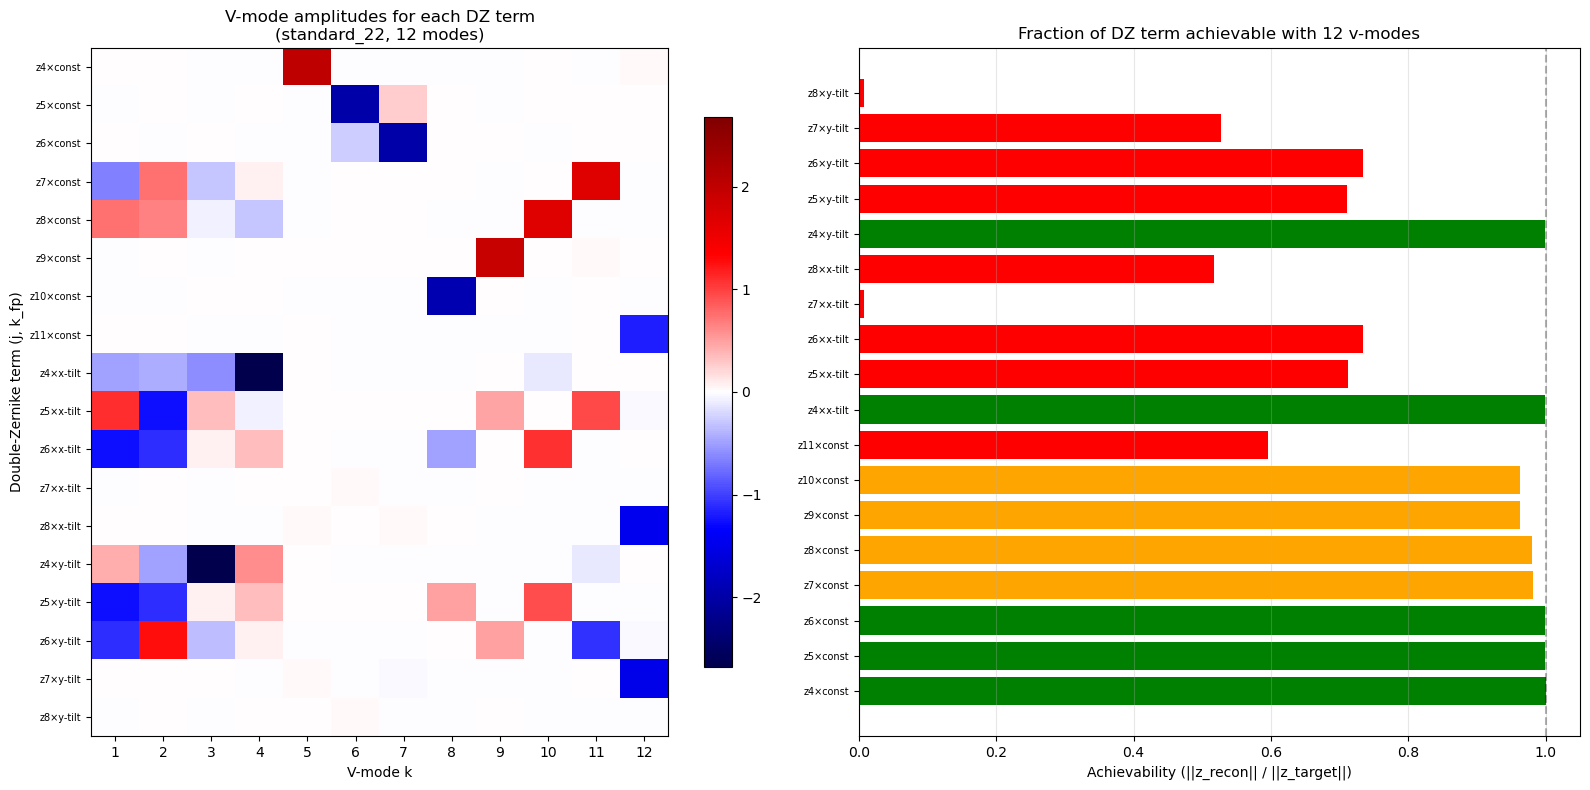

In [29]:
# Build the DZ → v-mode amplitude matrix
n_trunc = n_modes_truncated[default_dof_set]
amp_matrix = np.zeros((n_dz, n_trunc))
dz_labels = []
for i, (j, kfp) in enumerate(dz_term_list):
    amp_matrix[i, :] = dz_vmode_amps[(j, kfp)]
    dz_labels.append(f'z{j}×{fp_zernike_names[kfp]}')

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Heatmap of v-mode amplitudes
vmax = np.max(np.abs(amp_matrix))
im = axes[0].imshow(amp_matrix, cmap='seismic', vmin=-vmax, vmax=vmax, aspect='auto')
axes[0].set_xlabel('V-mode k')
axes[0].set_xticks(range(n_trunc), [str(k+1) for k in range(n_trunc)])
axes[0].set_ylabel('Double-Zernike term (j, k_fp)')
axes[0].set_yticks(range(n_dz), dz_labels, fontsize=7)
axes[0].set_title(f'V-mode amplitudes for each DZ term\n({default_dof_set}, {n_trunc} modes)')
fig.colorbar(im, ax=axes[0], shrink=0.8)

# Achievability bar chart
achiev = [dz_achievable[(j, kfp)] for j, kfp in dz_term_list]
bar_colors = ['green' if a > 0.99 else 'orange' if a > 0.9 else 'red' for a in achiev]
axes[1].barh(range(n_dz), achiev, color=bar_colors)
axes[1].set_yticks(range(n_dz), dz_labels, fontsize=7)
axes[1].set_xlabel('Achievability (||z_recon|| / ||z_target||)')
axes[1].set_title(f'Fraction of DZ term achievable with {n_trunc} v-modes')
axes[1].axvline(1.0, color='k', ls='--', alpha=0.3)
axes[1].set_xlim(0, 1.05)
axes[1].grid(alpha=0.3, axis='x')

fig.tight_layout()
plt.show()

### 10.3 Crosstalk Matrix

The crosstalk matrix C(i, j) shows: when we try to correct DZ term i using the retained v-modes,
how much of DZ term j gets excited. Diagonal = self-correction (should be ~1 for achievable terms).
Off-diagonal = crosstalk (should be ~0 for clean corrections).

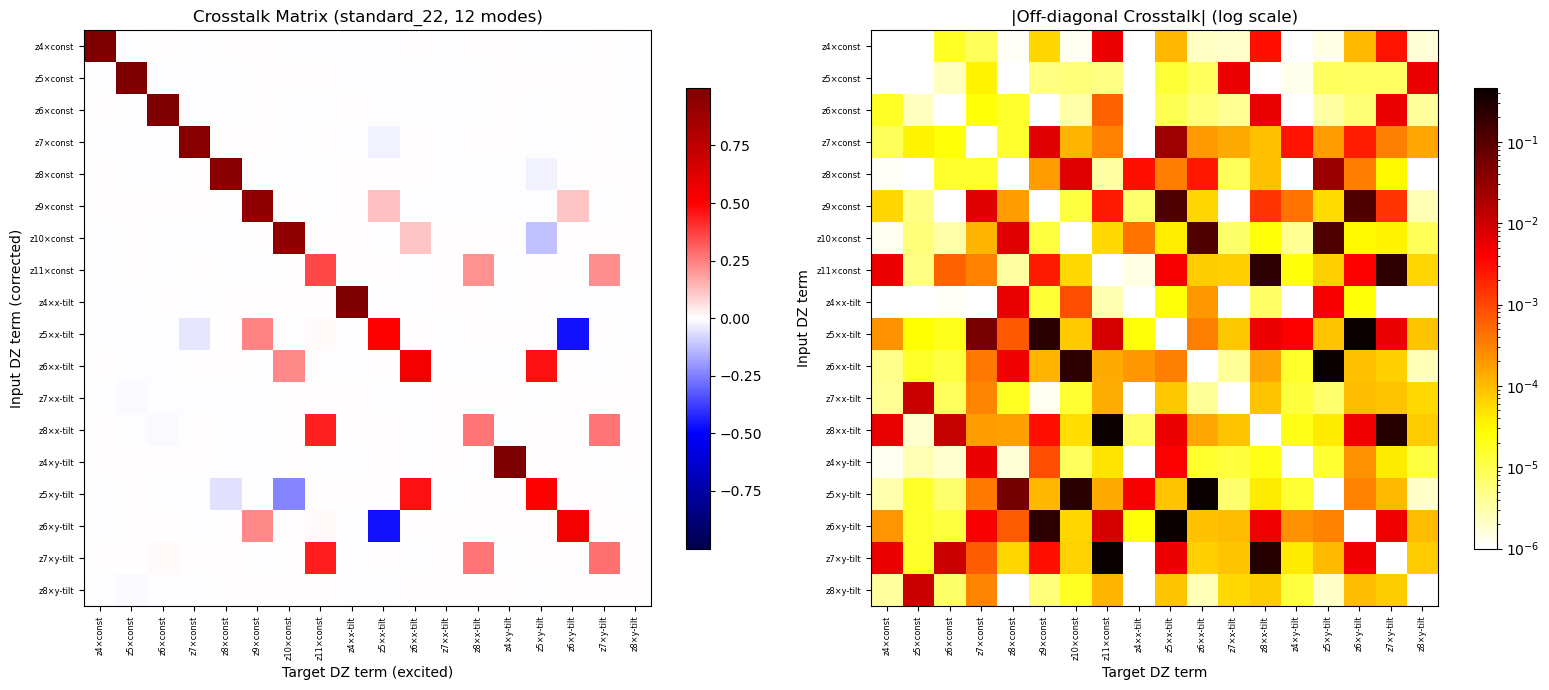


Max off-diagonal crosstalk per input DZ term:
  z4×  const: max |crosstalk| = 5.2842e-03  (worst: z11×const)
  z5×  const: max |crosstalk| = 5.3779e-03  (worst: z8×y-tilt)
  z6×  const: max |crosstalk| = 6.0748e-03  (worst: z8×x-tilt)
  z7×  const: max |crosstalk| = 2.6159e-02  (worst: z5×x-tilt)
  z8×  const: max |crosstalk| = 2.7732e-02  (worst: z5×y-tilt)
  z9×  const: max |crosstalk| = 1.1935e-01  (worst: z5×x-tilt)
  z10×  const: max |crosstalk| = 1.1965e-01  (worst: z5×y-tilt)
  z11×  const: max |crosstalk| = 2.2204e-01  (worst: z7×y-tilt)
  z4× x-tilt: max |crosstalk| = 5.8877e-03  (worst: z8×const)
  z5× x-tilt: max |crosstalk| = 4.6178e-01  (worst: z6×y-tilt)
  z6× x-tilt: max |crosstalk| = 4.6120e-01  (worst: z5×y-tilt)
  z7× x-tilt: max |crosstalk| = 1.0712e-02  (worst: z5×const)
  z8× x-tilt: max |crosstalk| = 4.3538e-01  (worst: z11×const)
  z4× y-tilt: max |crosstalk| = 5.6098e-03  (worst: z7×const)
  z5× y-tilt: max |crosstalk| = 4.6120e-01  (worst: z6×x-tilt)
  z6× y-t

In [30]:
# Build the crosstalk matrix
# C[i, j] = when correcting DZ term i, how much of DZ term j appears
n_trunc = n_modes_truncated[default_dof_set]
crosstalk_matrix = np.zeros((n_dz, n_dz))

for i, (j_i, kfp_i) in enumerate(dz_term_list):
    xtalk = dz_crosstalk[(j_i, kfp_i)]
    for ii, (j_ii, kfp_ii) in enumerate(dz_term_list):
        crosstalk_matrix[i, ii] = xtalk.get((j_ii, kfp_ii), 0.0)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Full crosstalk matrix
vmax = np.max(np.abs(crosstalk_matrix))
im = axes[0].imshow(crosstalk_matrix, cmap='seismic', vmin=-vmax, vmax=vmax, aspect='auto')
axes[0].set_xlabel('Target DZ term (excited)')
axes[0].set_ylabel('Input DZ term (corrected)')
axes[0].set_xticks(range(n_dz), dz_labels, rotation=90, fontsize=6)
axes[0].set_yticks(range(n_dz), dz_labels, fontsize=6)
axes[0].set_title(f'Crosstalk Matrix ({default_dof_set}, {n_trunc} modes)')
fig.colorbar(im, ax=axes[0], shrink=0.8)

# Off-diagonal crosstalk magnitude (log scale)
offdiag = crosstalk_matrix.copy()
np.fill_diagonal(offdiag, 0)
vmax_off = np.max(np.abs(offdiag))
if vmax_off > 0:
    im2 = axes[1].imshow(np.abs(offdiag), norm=colors.LogNorm(vmin=1e-6, vmax=max(vmax_off, 1e-5)),
                          aspect='auto', cmap='hot_r')
else:
    im2 = axes[1].imshow(np.abs(offdiag), aspect='auto', cmap='hot_r')
axes[1].set_xlabel('Target DZ term')
axes[1].set_ylabel('Input DZ term')
axes[1].set_xticks(range(n_dz), dz_labels, rotation=90, fontsize=6)
axes[1].set_yticks(range(n_dz), dz_labels, fontsize=6)
axes[1].set_title(f'|Off-diagonal Crosstalk| (log scale)')
fig.colorbar(im2, ax=axes[1], shrink=0.8)

fig.tight_layout()
plt.show()

# Print max off-diagonal crosstalk per DZ term
print(f'\nMax off-diagonal crosstalk per input DZ term:')
for i, (j, kfp) in enumerate(dz_term_list):
    row = offdiag[i, :]
    max_xt = np.max(np.abs(row))
    if max_xt > 1e-6:
        worst_idx = np.argmax(np.abs(row))
        j_w, kfp_w = dz_term_list[worst_idx]
        print(f'  z{j}×{fp_zernike_names[kfp]:>7s}: max |crosstalk| = {max_xt:.4e}  '
              f'(worst: z{j_w}×{fp_zernike_names[kfp_w]})')
    else:
        print(f'  z{j}×{fp_zernike_names[kfp]:>7s}: CLEAN (max |crosstalk| < 1e-6)')

### 10.4 V-Mode Recipes for Individual Double-Zernike Terms

For selected double-Zernike terms, show the v-mode amplitude bar charts and verify
that the reconstruction matches only the target term.

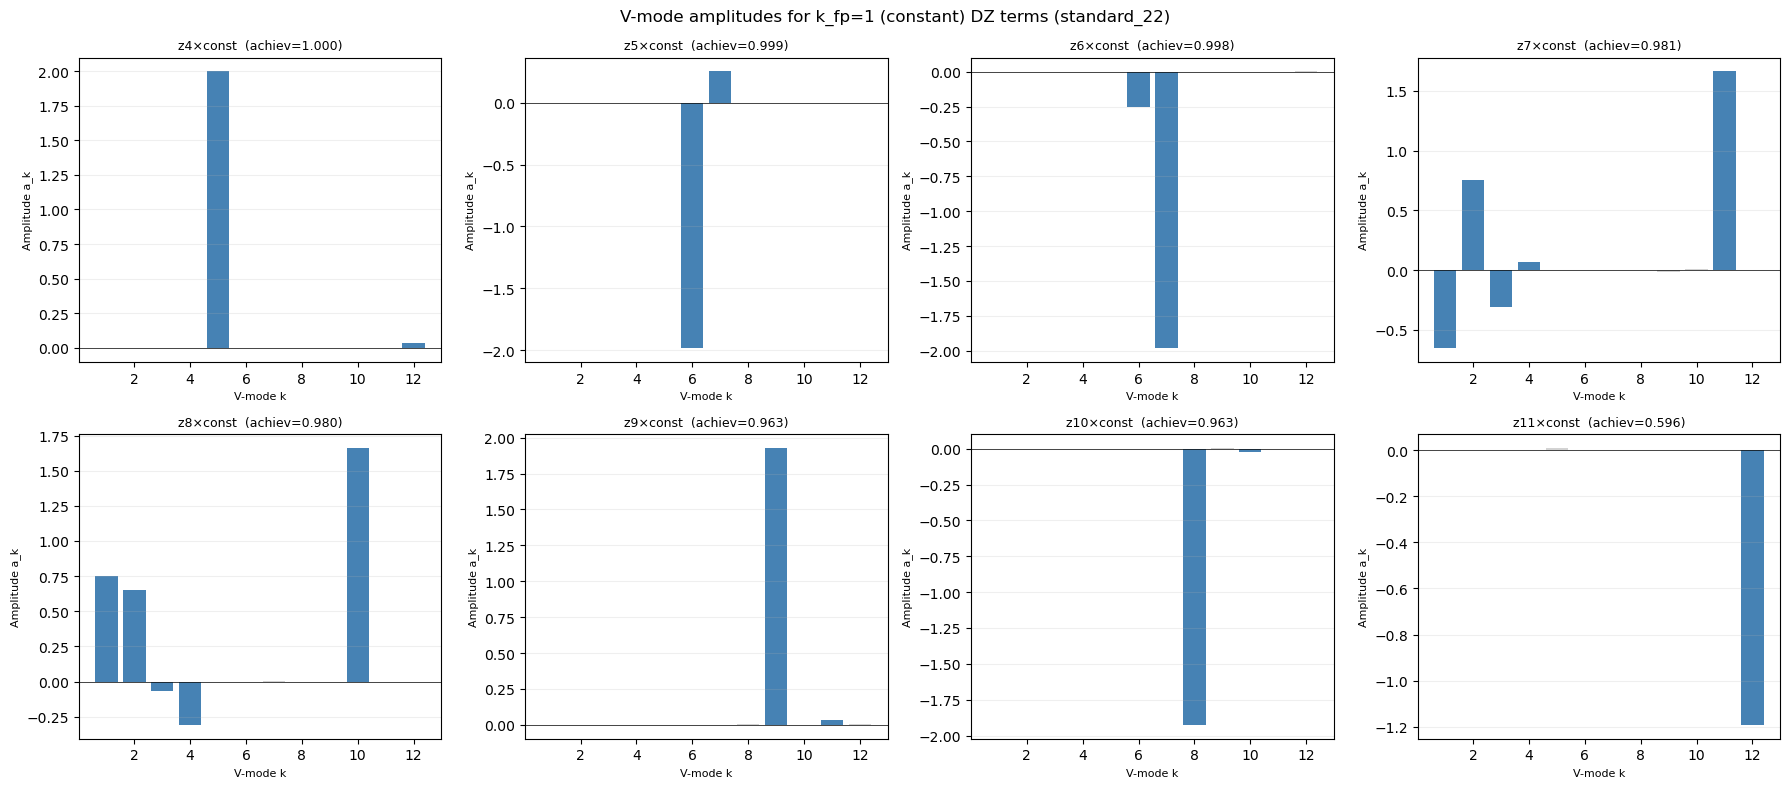

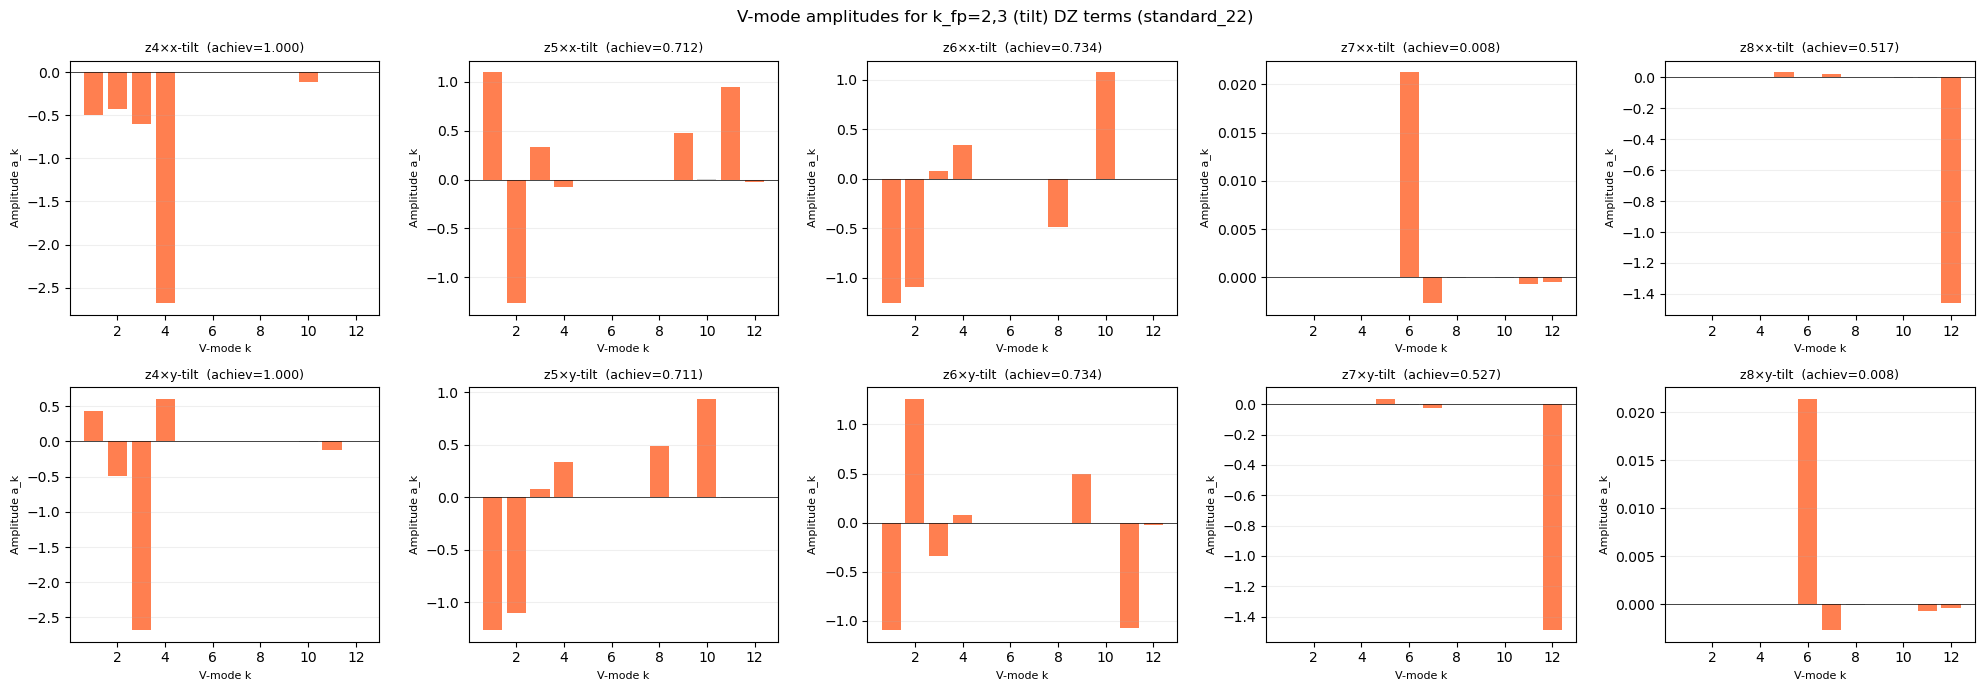

In [31]:
# Detailed plots for k_fp=1 (constant) DZ terms: z4-z11
r = svd_results[default_dof_set]
U = r['U']
n_trunc = n_modes_truncated[default_dof_set]

dz_kfp1 = [(j, 1) for j in range(4, 12)]
n_plots = len(dz_kfp1)

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for idx, (ax, (j, kfp)) in enumerate(zip(axes.flat, dz_kfp1)):
    a = dz_vmode_amps[(j, kfp)]
    bar_colors = ['steelblue' if abs(v) > 0.01 * np.max(np.abs(a)) else 'lightgray' for v in a]
    ax.bar(np.arange(1, n_trunc + 1), a, color=bar_colors)
    ax.set_xlabel('V-mode k', fontsize=8)
    ax.set_ylabel('Amplitude a_k', fontsize=8)
    achiev = dz_achievable[(j, kfp)]
    ax.set_title(f'z{j}×const  (achiev={achiev:.3f})', fontsize=9)
    ax.grid(alpha=0.2, axis='y')
    ax.axhline(0, color='k', lw=0.5)

fig.suptitle(f'V-mode amplitudes for k_fp=1 (constant) DZ terms ({default_dof_set})', fontsize=12)
fig.tight_layout()
plt.show()

# Detailed plots for k_fp=2 and k_fp=3 (x-tilt and y-tilt): z4-z8
dz_kfp23 = [(j, 2) for j in range(4, 9)] + [(j, 3) for j in range(4, 9)]
n_plots = len(dz_kfp23)

fig, axes = plt.subplots(2, 5, figsize=(20, 7))
for idx, (ax, (j, kfp)) in enumerate(zip(axes.flat, dz_kfp23)):
    a = dz_vmode_amps[(j, kfp)]
    bar_colors = ['coral' if abs(v) > 0.01 * np.max(np.abs(a)) else 'lightgray' for v in a]
    ax.bar(np.arange(1, n_trunc + 1), a, color=bar_colors)
    ax.set_xlabel('V-mode k', fontsize=8)
    ax.set_ylabel('Amplitude a_k', fontsize=8)
    achiev = dz_achievable[(j, kfp)]
    ax.set_title(f'z{j}×{fp_zernike_names[kfp]}  (achiev={achiev:.3f})', fontsize=9)
    ax.grid(alpha=0.2, axis='y')
    ax.axhline(0, color='k', lw=0.5)

fig.suptitle(f'V-mode amplitudes for k_fp=2,3 (tilt) DZ terms ({default_dof_set})', fontsize=12)
fig.tight_layout()
plt.show()

### 10.5 Verification: Reconstruct Each DZ Term and Check Purity

For each double-Zernike term, reconstruct the wavefront from the v-mode recipe and decompose 
it back into all double-Zernike coefficients. Verify that only the intended term is non-zero.

In [32]:
# Detailed verification for each DZ term
r = svd_results[default_dof_set]
U = r['U']
n_trunc = n_modes_truncated[default_dof_set]

print(f'DZ Term Purity Check ({default_dof_set}, {n_trunc} retained modes)')
print(f'{"DZ term":>16s} {"self coeff":>11s} {"achievable":>11s} {"max xtalk":>11s} {"xtalk term":>16s} {"pure?":>6s}')
print('-' * 80)

n_clean = 0
n_total = 0
for j, kfp in dz_term_list:
    dz_vec = dz_vectors[(j, kfp)]
    
    # Project onto retained v-modes and reconstruct
    a = U[:, :n_trunc].T @ dz_vec
    z_recon = U[:, :n_trunc] @ a
    
    # Decompose reconstruction into all DZ terms
    recon_coeffs = decompose_into_dz(z_recon, dz_vectors)
    
    self_coeff = recon_coeffs.get((j, kfp), 0.0)
    achiev = dz_achievable[(j, kfp)]
    
    # Find worst crosstalk
    max_xtalk = 0.0
    worst_term = None
    for (jj, kkfp), c in recon_coeffs.items():
        if (jj, kkfp) != (j, kfp) and abs(c) > max_xtalk:
            max_xtalk = abs(c)
            worst_term = (jj, kkfp)
    
    is_pure = max_xtalk < 1e-4 * abs(self_coeff) if abs(self_coeff) > 0 else max_xtalk < 1e-10
    n_total += 1
    if is_pure:
        n_clean += 1
    
    worst_str = f'z{worst_term[0]}×{fp_zernike_names[worst_term[1]]}' if worst_term else 'n/a'
    pure_str = 'YES' if is_pure else 'NO'
    
    print(f'z{j}×{fp_zernike_names[kfp]:>7s}  {self_coeff:>11.6f}  {achiev:>11.4f}  '
          f'{max_xtalk:>11.2e}  {worst_str:>16s}  {pure_str:>6s}')

print(f'\nSummary: {n_clean}/{n_total} DZ terms have pure (no crosstalk) v-mode recipes')
print(f'Note: "pure" means max |crosstalk| < 1e-4 × |self coefficient|')

DZ Term Purity Check (standard_22, 12 retained modes)
         DZ term  self coeff  achievable   max xtalk       xtalk term  pure?
--------------------------------------------------------------------------------
z4×  const     0.999927       1.0000     5.28e-03         z11×const      NO
z5×  const     0.997005       0.9985     5.38e-03         z8×y-tilt      NO
z6×  const     0.996972       0.9985     6.07e-03         z8×x-tilt      NO
z7×  const     0.962226       0.9809     2.62e-02         z5×x-tilt      NO
z8×  const     0.960280       0.9799     2.77e-02         z5×y-tilt      NO
z9×  const     0.927883       0.9633     1.19e-01         z5×x-tilt      NO
z10×  const     0.927343       0.9630     1.20e-01         z5×y-tilt      NO
z11×  const     0.355393       0.5961     2.22e-01         z7×y-tilt      NO
z4× x-tilt     0.999154       0.9996     5.89e-03          z8×const      NO
z5× x-tilt     0.507337       0.7123     4.62e-01         z6×y-tilt      NO
z6× x-tilt     0.539048   